In [1]:
# Project-root setup (auto-injected during notebook reorg 2026-05-06).
import sys as _sys
from pathlib import Path as _Path
_p = _Path.cwd().resolve()
while _p != _p.parent and not (_p / "pyproject.toml").exists():
    _p = _p.parent
PROJECT_ROOT = _p if (_p / "pyproject.toml").exists() else _Path.cwd()
if str(PROJECT_ROOT) not in _sys.path:
    _sys.path.insert(0, str(PROJECT_ROOT))
# Also add notebook_modules/ so `from twopoint_lockin import ...` etc. work
# without per-notebook sys.path tweaks. The five .py modules used by these
# notebooks live there now (lockin_extensions, multipoint_lockin_program,
# nv_magnetometry_analysis, odmr_sensitivity, twopoint_lockin).
_nb_modules_dir = PROJECT_ROOT / "notebook_modules"
if _nb_modules_dir.exists() and str(_nb_modules_dir) not in _sys.path:
    _sys.path.insert(0, str(_nb_modules_dir))
print(f"PROJECT_ROOT: {PROJECT_ROOT}")


PROJECT_ROOT: /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project


# Import and setup

In [2]:
%load_ext autoreload
%matplotlib inline
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from copy import copy
import qickdawg as qd
from scipy.optimize import curve_fit

# ===== EDIT THIS: Set your RFSoC IP address =====
RFSOC_IP = '192.168.0.103'

qd.start_client(RFSOC_IP)
print(f"Connected to RFSoC at {RFSOC_IP}")

Connected to RFSoC at 192.168.0.103


In [3]:
default_config = qd.NVConfiguration()

# ADC channel: 0 or 1 (run diagnostic above if unsure which has your photodiode)
# 0 for ADC_D and 1 for ADC_C
default_config.adc_channel = 0
default_config.mw_channel = 1
default_config.mw_nqz = 1
default_config.mw_gain = 10500
default_config.laser_gate_pmod = 0
default_config.relax_delay_tns = 500000 
default_config.readout_integration_tus = 213  # max ~106.7 µs; auto-sets _treg and _tns

print("Default configuration:")
print(f"  ADC channel:     {default_config.adc_channel}")
print(f"  MW channel:      {default_config.mw_channel}")
print(f"  MW gain:         {default_config.mw_gain}")
print(f"  Relax delay:     {default_config.relax_delay_tns:.0f} ns")
print(f"  Readout int.:    {default_config.readout_integration_tus:.2f} µs  ({default_config.readout_integration_treg} treg)")

Default configuration:
  ADC channel:     0
  MW channel:      1
  MW gain:         10500
  Relax delay:     500000 ns
  Readout int.:    213.00 µs  (65434 treg)


# ODMR

In [4]:
# =============================================================================
# ODMR sweep — edit ALL parameters below, then run this cell once.
# Builds config, runs LockinODMR, saves full sweep to CSV (MW on / MW off / contrast).
# =============================================================================
import pandas as pd
from pathlib import Path
from datetime import datetime
import importlib

from IPython.display import FileLink, display

# --- Microwave & timing ---
ODMR_MW_GAIN = 10500              # 0–32767; ↑ if contrast weak, ↓ if saturated
ODMR_PRE_INIT = True             # MW+laser prepulse before sweep
ODMR_REPS = 10                   # averages per frequency point
ODMR_RELAX_DELAY_TREG = 1000    # delay register units between MW on/off segments 100000. Normal = 500, Completely MW Off = 500000 

# --- ADC readout integration (photodiode PL averaging time) ---
ODMR_READOUT_INTEGRATION_TUS = 213   # or set e.g. 50.0 (microseconds)

# --- Frequency sweep (MHz) ---
MW_FREQ_START_MHZ = 2600
MW_FREQ_STOP_MHZ = 3100
MW_FREQ_STEP_MHZ = 1             # step size (MHz); narrow range once peaks are known. Try 0.5 or 0.25 MHz it will make the np.gradient for Yizhou algorithm more accurate
# Instead of delta, you can use a fixed point count, e.g.:
#   config_odmr.add_linear_sweep("mw", "fMHz", start=2700, stop=3000, nsweep_points=301)
# (then comment out the add_linear_sweep call in the build block below and paste there)

# --- CSV export ---
SAVE_ODMR_CSV = True             # set False to only acquire (still defines d, prog_odmr for plots)

# --- If reference should be flat but shows dips: try True (explicit low-gain pulse in ref. window) ---
ODMR_REFERENCE_ZERO_GAIN_PULSE = False
ODMR_REFERENCE_PULSE_GAIN = 1       # use 1 if gain 0 faults; increase only if needed
# --- Only if reference is flat and signal is not (mis-labeled shots), try True ---
ODMR_LOCKIN_SWAP_SIGNAL_REFERENCE = False

# --- Build configuration (inherits adc_channel, mw_channel, laser from default_config) ---
config_odmr = copy(default_config)
config_odmr.odmr_reference_zero_gain_pulse = ODMR_REFERENCE_ZERO_GAIN_PULSE
config_odmr.odmr_reference_pulse_gain = ODMR_REFERENCE_PULSE_GAIN
config_odmr.odmr_lockin_swap_signal_reference = ODMR_LOCKIN_SWAP_SIGNAL_REFERENCE
config_odmr.readout_integration_tus = ODMR_READOUT_INTEGRATION_TUS
config_odmr.mw_gain = ODMR_MW_GAIN
config_odmr.pre_init = ODMR_PRE_INIT
config_odmr.reps = ODMR_REPS
config_odmr.relax_delay_treg = ODMR_RELAX_DELAY_TREG
config_odmr.add_linear_sweep(
    "mw", "fMHz",
    start=MW_FREQ_START_MHZ,
    stop=MW_FREQ_STOP_MHZ,
    delta=MW_FREQ_STEP_MHZ,
)

print("ODMR configuration:")
print(f"  ADC channel: {config_odmr.adc_channel}  MW channel: {config_odmr.mw_channel}  gain: {config_odmr.mw_gain}")
print(f"  Sweep: {config_odmr.mw_start_fMHz:.3f} → {config_odmr.mw_end_fMHz:.3f} MHz  ({config_odmr.nsweep_points} pts)")
print(f"  reps: {config_odmr.reps}  est. time: {qd.LockinODMR(config_odmr).total_time():.1f} s")

prog_odmr = qd.LockinODMR(config_odmr)
d = prog_odmr.acquire(progress=True)
print("Acquisition done.")

if SAVE_ODMR_CSV:
    odmr_df = pd.DataFrame(
        {
            "frequency_MHz": np.asarray(d.frequencies, dtype=float),
            "photoluminescence_mw_on_ADC": np.asarray(d.signal, dtype=float),
            "photoluminescence_mw_off_ADC": np.asarray(d.reference, dtype=float),
            "contrast_ADC": np.asarray(d.contrast, dtype=float),
            "contrast_percent": np.asarray(d.contrast_percent, dtype=float),
        }
    )
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    # Save ODMR sweep CSV to the categorized data store under PROJECT_ROOT/data/odmr_sweeps/
    # so all ODMR runs land in one place regardless of which subfolder the
    # notebook is launched from. PROJECT_ROOT is set by the project_root_setup cell.
    odmr_csv_dir = PROJECT_ROOT / "data" / "odmr_sweeps"
    odmr_csv_dir.mkdir(parents=True, exist_ok=True)
    csv_path = odmr_csv_dir / f"odmr_sweep_{ts}.csv"
    odmr_df.to_csv(csv_path, index=False)
    LAST_ODMR_CSV = csv_path
    LAST_ODMR_DF = odmr_df.copy()
    print(f"CSV: {len(odmr_df)} rows → {csv_path.resolve()}")
    display(FileLink(csv_path.name))


Requested 2600 to 3100 by 1
Instead using 2600.00000038147 to 3099.9998096466065 by 0.9999996185302735 in 501 steps
ODMR configuration:
  ADC channel: 0  MW channel: 1  gain: 10500
  Sweep: 2600.000 → 3100.000 MHz  (501 pts)
  reps: 10  est. time: 2.2 s


  0%|          | 0/5010 [00:00<?, ?it/s]

Acquisition done.
CSV: 501 rows → /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/odmr_sweeps/odmr_sweep_20260514_120924.csv


/Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/Modules/odmr_sweep_20260514_120924.csv

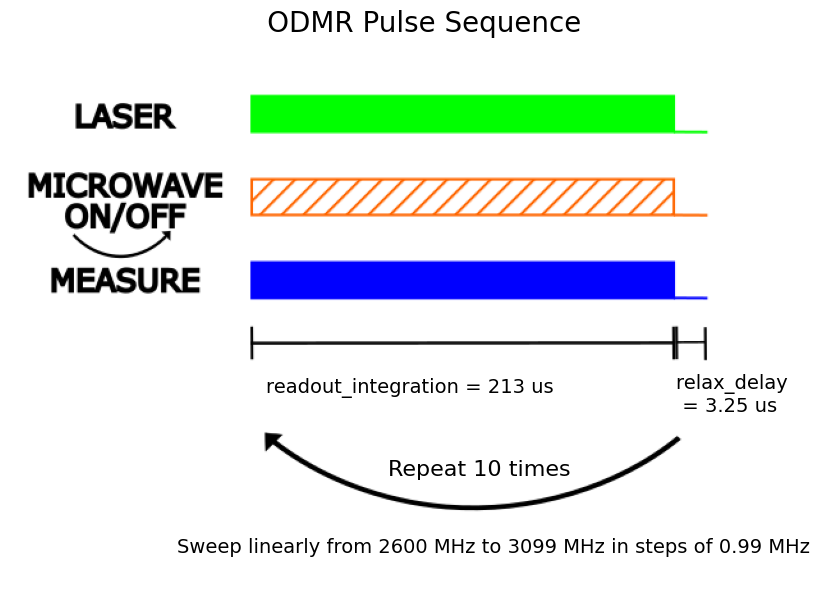

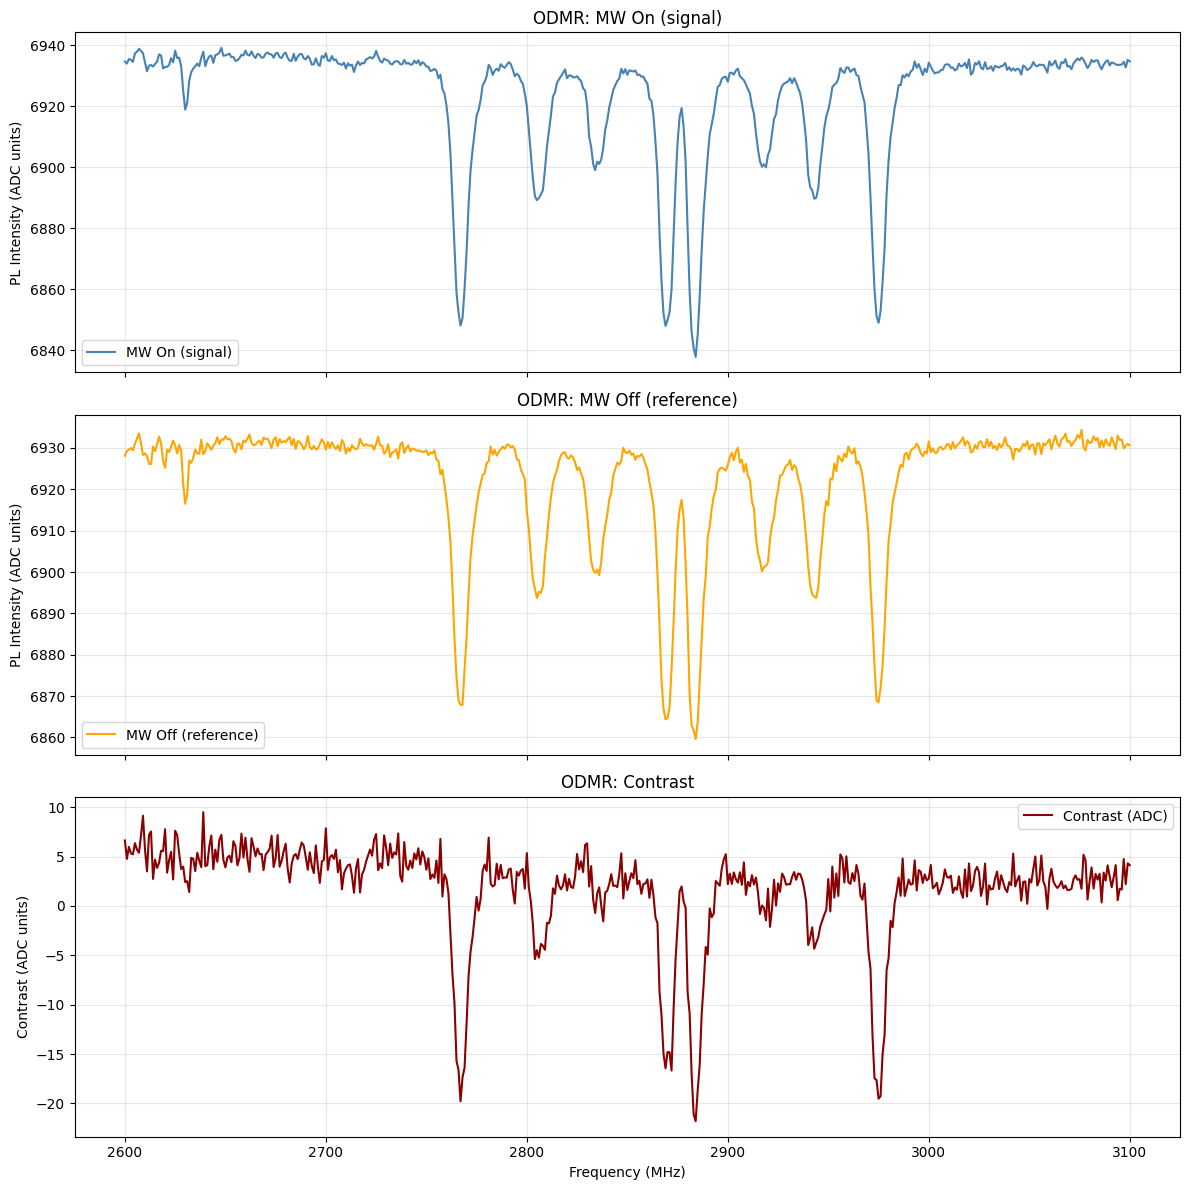

In [5]:
qd.LockinODMR.plot_sequence(config_odmr)

# Plot ODMR spectrum with subplots for MW On, MW Off, and Contrast
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# Plot MW On (signal)
axes[0].plot(d.frequencies, d.signal, label='MW On (signal)', color='steelblue')
axes[0].set_ylabel('PL Intensity (ADC units)')
axes[0].set_title('ODMR: MW On (signal)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot MW Off (reference)
axes[1].plot(d.frequencies, d.reference, label='MW Off (reference)', color='orange')
axes[1].set_ylabel('PL Intensity (ADC units)')
axes[1].set_title('ODMR: MW Off (reference)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot Contrast
axes[2].plot(d.frequencies, d.contrast, label='Contrast (ADC)', color='darkred')
axes[2].set_xlabel('Frequency (MHz)')
axes[2].set_ylabel('Contrast (ADC units)')
axes[2].set_title('ODMR: Contrast')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

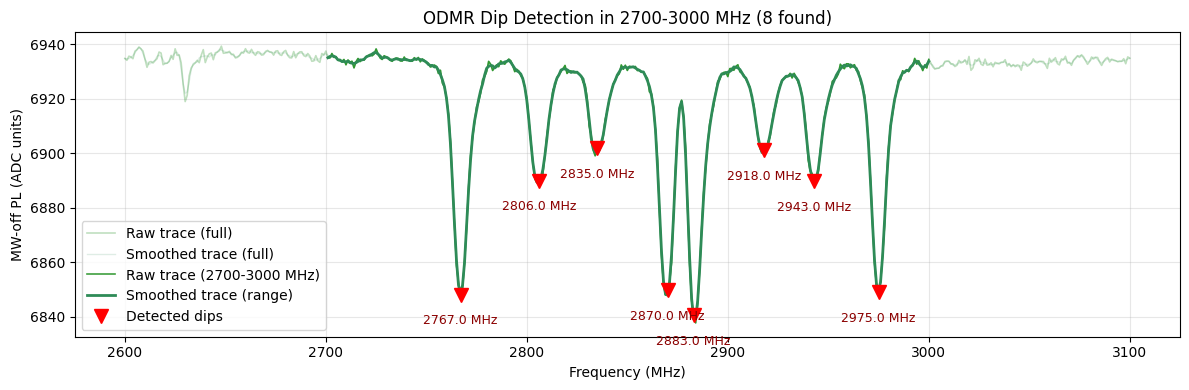

Trace source: Current acquisition (`d.reference`)
Analyzed range: 2700 to 3000 MHz
Using column 1 as x and column 3 as y when a CSV path is provided.
Prominence threshold used: 9.04 ADC
Detected ODMR dips in selected range:
  Dip 1: 2767.00 MHz  (6848.1049 ADC)
  Dip 2: 2806.00 MHz  (6889.9748 ADC)
  Dip 3: 2835.00 MHz  (6901.8513 ADC)
  Dip 4: 2870.00 MHz  (6849.8094 ADC)
  Dip 5: 2883.00 MHz  (6840.6525 ADC)
  Dip 6: 2918.00 MHz  (6901.0088 ADC)
  Dip 7: 2943.00 MHz  (6889.7064 ADC)
  Dip 8: 2975.00 MHz  (6848.9653 ADC)
Suggested resonance frequency (deepest dip in range): 2883.00 MHz


In [6]:
# Detect and mark ODMR dips from frequency (column 1) vs MW-off PL (column 3)
import pandas as pd
from pathlib import Path
from scipy.signal import find_peaks as scipy_find_peaks, savgol_filter

ODMR_CSV_PATH = None
# ODMR_CSV_PATH = Path("/Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/Initial Test/odmr_sweep_20260320_132708.csv")
# Set ODMR_CSV_PATH to a saved CSV to analyze first-column frequency vs third-column PL.
# Leave it as None to analyze the current in-memory sweep (`d.reference`).


def load_odmr_trace(csv_path=None):
    if csv_path is None:
        return (
            np.asarray(d.frequencies, dtype=float),
            np.asarray(d.signal, dtype=float),
            'MW-off reference',
            'Current acquisition (`d.reference`)'
        )

    odmr_df = pd.read_csv(Path(csv_path))
    if {'frequency_MHz', 'photoluminescence_mw_off_ADC'}.issubset(odmr_df.columns):
        x = odmr_df['frequency_MHz'].to_numpy(dtype=float)
        y = odmr_df['photoluminescence_mw_off_ADC'].to_numpy(dtype=float)
        y_label = 'photoluminescence_mw_off_ADC'
    else:
        x = odmr_df.iloc[:, 0].to_numpy(dtype=float)
        y = odmr_df.iloc[:, 2].to_numpy(dtype=float)
        y_label = odmr_df.columns[2]

    return x, y, y_label, str(Path(csv_path).resolve())


def find_odmr_dips(
    frequencies,
    signal,
    n_dips=4,
    prominence_factor=0.4,
    min_prominence=6.0,
    smooth_window=7,
    polyorder=2,
    min_distance_pts=3,
    freq_min=None,
    freq_max=None,
):
    """Find ODMR transmission dips (local minima) in the selected PL trace within a frequency range."""
    x = np.asarray(frequencies, dtype=float)
    y = np.asarray(signal, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    # Limit analysis to within freq_min and freq_max if given
    if freq_min is not None or freq_max is not None:
        idx_range = np.ones_like(x, dtype=bool)
        if freq_min is not None:
            idx_range &= x >= freq_min
        if freq_max is not None:
            idx_range &= x <= freq_max
        x = x[idx_range]
        y = y[idx_range]

    if len(x) < 5:
        raise ValueError('Need at least 5 finite points to detect ODMR dips.')

    w = int(max(5, smooth_window))
    if w % 2 == 0:
        w += 1
    if w >= len(y):
        w = len(y) - 1 if len(y) % 2 == 0 else len(y)

    if w < polyorder + 2:
        y_smooth = y.copy()
    else:
        y_smooth = savgol_filter(y, window_length=w, polyorder=min(polyorder, w - 2), mode='interp')

    trend = np.polyval(np.polyfit(x, y_smooth, 1), x)
    y_detr = y_smooth - trend

    prominence = max(float(min_prominence), np.std(y_detr) * float(prominence_factor))
    dip_idx, props = scipy_find_peaks(
        -y_detr,
        prominence=prominence,
        distance=max(1, int(min_distance_pts)),
    )

    if len(dip_idx) == 0:
        return dip_idx, y_smooth, y_detr, props, prominence, x, y

    prom_arr = props.get('prominences', np.zeros(len(dip_idx), dtype=float))
    keep = np.argsort(prom_arr)[-int(n_dips):]
    dip_idx = dip_idx[keep]
    dip_idx = dip_idx[np.argsort(x[dip_idx])]
    return dip_idx, y_smooth, y_detr, props, prominence, x, y


# Restrict frequency range for dip detection: 2700 to 3000 MHz
FREQ_MIN = 2700
FREQ_MAX = 3000

frequencies, trace, trace_label, trace_source = load_odmr_trace(ODMR_CSV_PATH)
dip_idx, trace_smooth, trace_detr, dip_props, used_prominence, x_range, y_range = find_odmr_dips(
    frequencies,
    trace,
    n_dips=8,
    prominence_factor=0.4,
    min_prominence=4.0,
    smooth_window=7,
    polyorder=2,
    min_distance_pts=3,
    freq_min=FREQ_MIN,
    freq_max=FREQ_MAX,
)

plt.figure(figsize=(12, 4))

# Plot full raw and smoothed traces for visual context
plt.plot(frequencies, trace, color='green', linewidth=1.2, alpha=0.25, label='Raw trace (full)')
plt.plot(frequencies, savgol_filter(trace, window_length=7 if len(trace) > 7 else 5, polyorder=2 if len(trace) > 2 else 1, mode='interp'), color='seagreen', linewidth=1.0, alpha=0.15, label='Smoothed trace (full)')

# Plot zoomed-in range (2700-3000)
plt.plot(x_range, y_range, color='green', linewidth=1.2, alpha=0.75, label=f'Raw trace ({FREQ_MIN}-{FREQ_MAX} MHz)')
plt.plot(x_range, trace_smooth, color='seagreen', linewidth=2.0, label='Smoothed trace (range)')

if len(dip_idx) > 0:
    plt.plot(x_range[dip_idx], y_range[dip_idx], 'rv', markersize=10, label='Detected dips')
    for i, idx in enumerate(dip_idx):
        plt.annotate(
            f"{x_range[idx]:.1f} MHz",
            xy=(x_range[idx], y_range[idx]),
            xytext=(0, -14),
            textcoords='offset points',
            ha='center',
            va='top',
            fontsize=9,
            color='darkred',
        )

plt.ylabel('MW-off PL (ADC units)' if trace_label == 'MW-off reference' else trace_label)
plt.xlabel('Frequency (MHz)')
plt.title(f'ODMR Dip Detection in {FREQ_MIN}-{FREQ_MAX} MHz ({len(dip_idx)} found)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Trace source: {trace_source}')
print(f'Analyzed range: {FREQ_MIN} to {FREQ_MAX} MHz')
print('Using column 1 as x and column 3 as y when a CSV path is provided.')
print(f'Prominence threshold used: {used_prominence:.2f} ADC')

if len(dip_idx) == 0:
    print('No ODMR dips found in the specified range. Lower `min_prominence` or reduce `smooth_window`.')
else:
    print('Detected ODMR dips in selected range:')
    for i, idx in enumerate(dip_idx):
        print(f"  Dip {i+1}: {x_range[idx]:.2f} MHz  ({y_range[idx]:.4f} ADC)")

    deepest_idx = dip_idx[np.argmin(y_range[dip_idx])]
    print(f'Suggested resonance frequency (deepest dip in range): {x_range[deepest_idx]:.2f} MHz')


# Lockin

## Generate 16 parked frequencies

Using ODMR for parked plan: /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/odmr_sweeps/odmr_sweep_20260514_120924.csv
ODMR source: /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/odmr_sweeps/odmr_sweep_20260514_120924.csv
Detected candidates: 8
Collapsed centers before rejection: [2766.915, 2805.993, 2834.825, 2869.587, 2883.528, 2918.096, 2942.708, 2974.996]
Kept centers: [2767.152, 2805.934, 2835.172, 2869.555, 2883.82, 2918.113, 2943.145, 2975.028]
Rejected centers: []
Parked plan written to: /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/parked_plan_odmr_sweep_20260514_120924.csv
Number of parked frequencies: 16 (8 transitions × 2 flanks)
Estimated bias field (mT): 2.1196, -0.5901, -3.4236


,block_index,transition_index,center_mhz,linewidth_mhz,f_minus_mhz,f_plus_mhz,slope_minus_per_mhz,slope_plus_per_mhz
0,1,0,2767.151855,10.357357,2761.973177,2772.330533,-0.001795,0.001172
1,2,1,2805.934310,14.842050,2798.513285,2813.355335,-0.000423,0.000461
2,3,2,2835.171881,14.538129,2827.902817,2842.440946,-0.000227,0.000374
3,4,3,2869.555392,16.424079,2861.343352,2877.767432,-0.000399,-0.001022
4,5,4,2883.820154,13.462549,2877.088880,2890.551429,-0.000304,0.000948
5,6,5,2918.112520,13.744112,2911.240464,2924.984576,-0.000417,0.000525
6,7,6,2943.144953,11.918597,2937.185655,2949.104252,-0.000701,0.000425
7,8,7,2975.028031,9.947783,2970.054140,2980.001923,-0.001707,0.001360


/Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/parked_plan_odmr_sweep_20260514_120924.csv

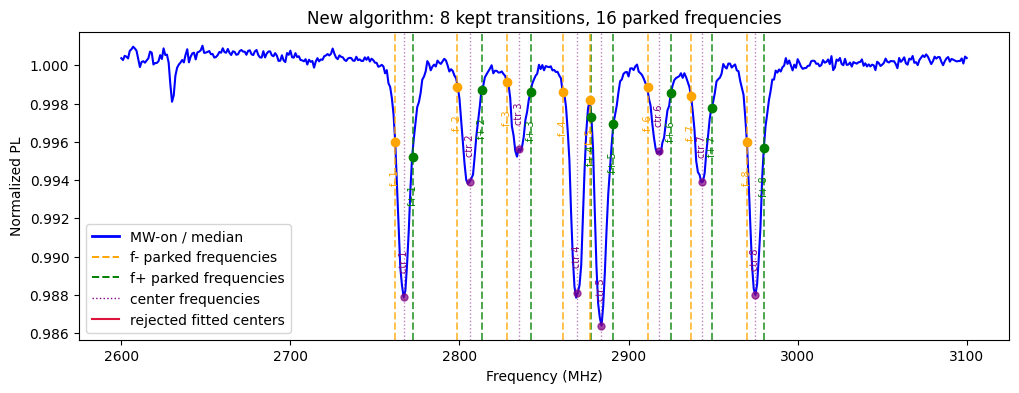

In [7]:
# Step 1 — Generate parked frequencies from the most recent ODMR sweep using the newer
# candidate clustering + local fitting + spurious-pair rejection workflow.

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import FileLink, display

# Locate NV_Magnetometry_Software-main.
_search_roots = [Path.cwd(), *Path.cwd().parents]
NV_REPO_DIR = None
for _root in _search_roots:
    candidate = _root / "NV_Magnetometry_Software-main"
    if (candidate / "nv_toolkit" / "operator_cli.py").exists():
        NV_REPO_DIR = candidate
        break
if NV_REPO_DIR is None:
    raise FileNotFoundError("NV_Magnetometry_Software-main not found relative to notebook directory")
if str(NV_REPO_DIR) not in sys.path:
    sys.path.insert(0, str(NV_REPO_DIR))

from nv_toolkit.peaks import (
    detect_baseline_corrected_dip_candidates,
    cluster_dip_candidates,
    collapse_candidate_clusters,
    fit_local_dips,
    reject_unpaired_peaks,
)
from nv_toolkit.tui import (
    ParkedFrequencyPlanEntry,
    _write_parked_plan_csv,
    _estimate_bias_field_mT,
)

# Pick the ODMR CSV.
odmr_dir = PROJECT_ROOT / "data" / "odmr_sweeps"
if "LAST_ODMR_CSV" in globals() and Path(LAST_ODMR_CSV).exists():
    ODMR_CSV_FOR_PLAN = Path(LAST_ODMR_CSV)
else:
    odmr_files = sorted(odmr_dir.glob("odmr_sweep_*.csv"))
    if not odmr_files:
        raise FileNotFoundError(f"No odmr_sweep_*.csv found in {odmr_dir}")
    ODMR_CSV_FOR_PLAN = odmr_files[-1]

print(f"Using ODMR for parked plan: {ODMR_CSV_FOR_PLAN}")

# Optional post-detection frequency window.
PARKED_FREQ_RANGE_MHZ = None

# New parking algorithm parameters.
SNR_THRESHOLD = 1.5
CLUSTER_MERGE_MHZ = 3.0
FIT_WINDOW_MHZ = 8.0
MAX_CENTERS = 8
FWHM_FLOOR_MHZ = 0.200
FWHM_FALLBACK_MHZ = 0.5

def _safe_fwhm_mhz(fwhm):
    fwhm = float(fwhm)
    return fwhm if fwhm > FWHM_FLOOR_MHZ + 0.01 else FWHM_FALLBACK_MHZ

# Load raw ODMR sweep and normalize MW-on signal.
_odmr_df = pd.read_csv(ODMR_CSV_FOR_PLAN)
freqs_mhz = _odmr_df["frequency_MHz"].to_numpy(dtype=float)
_mw_on = _odmr_df["photoluminescence_mw_on_ADC"].to_numpy(dtype=float)
measured = _mw_on / float(np.nanmedian(_mw_on))

# Candidate detection -> clustering -> local fits -> physical pair rejection.
candidates = detect_baseline_corrected_dip_candidates(
    freqs_mhz,
    measured,
    min_prominence_sigma=SNR_THRESHOLD,
)
clusters = cluster_dip_candidates(candidates, merge_distance_mhz=CLUSTER_MERGE_MHZ)
candidate_centers, cluster_rows = collapse_candidate_clusters(clusters, max_centers=MAX_CENTERS)

if PARKED_FREQ_RANGE_MHZ is not None:
    _low, _high = float(PARKED_FREQ_RANGE_MHZ[0]), float(PARKED_FREQ_RANGE_MHZ[1])
    _in_range = (candidate_centers >= _low) & (candidate_centers <= _high)
    _n_total = len(candidate_centers)
    candidate_centers = candidate_centers[_in_range]
    print(
        f"Parked-freq search restricted to {_low:.0f}-{_high:.0f} MHz: "
        f"kept {len(candidate_centers)} of {_n_total} collapsed centers."
    )
    if len(candidate_centers) == 0:
        raise RuntimeError("No candidate centers remain after PARKED_FREQ_RANGE_MHZ filtering.")

local_fits = fit_local_dips(
    freqs_mhz,
    measured,
    candidate_centers,
    window_mhz=FIT_WINDOW_MHZ,
    hyperfine_merge_mhz=0.0,
)
kept_fits, rejected_fits = reject_unpaired_peaks(
    local_fits,
    (float(np.nanmin(freqs_mhz)), float(np.nanmax(freqs_mhz))),
)
kept_fits = sorted(kept_fits, key=lambda fit: fit.center_mhz)
rejected_fits = sorted(rejected_fits, key=lambda fit: fit.center_mhz)

if len(kept_fits) == 0:
    raise RuntimeError("New parking algorithm rejected all fitted peaks.")

transition_centers = np.asarray([fit.center_mhz for fit in kept_fits], dtype=float)
gradient = np.gradient(measured, freqs_mhz)

parked_plan = []
for transition_index, fit in enumerate(kept_fits):
    center = float(fit.center_mhz)
    linewidth = _safe_fwhm_mhz(fit.linewidth_mhz)
    f_minus = center - linewidth / 2.0
    f_plus = center + linewidth / 2.0

    parked_plan.append(
        ParkedFrequencyPlanEntry(
            transition_index=int(transition_index),
            center_mhz=center,
            linewidth_mhz=linewidth,
            frequency_minus_mhz=f_minus,
            frequency_plus_mhz=f_plus,
            slope_minus_per_mhz=float(np.interp(f_minus, freqs_mhz, gradient)),
            slope_plus_per_mhz=float(np.interp(f_plus, freqs_mhz, gradient)),
        )
    )
parked_plan = tuple(parked_plan)

# Persist the plan as the canonical handoff CSV.
PARKED_PLAN_CSV = PROJECT_ROOT / "data" / "lockin_multipoint" / f"parked_plan_{ODMR_CSV_FOR_PLAN.stem}.csv"
PARKED_PLAN_CSV.parent.mkdir(parents=True, exist_ok=True)
_write_parked_plan_csv(PARKED_PLAN_CSV, parked_plan)

# Estimate bias field from kept transition centers.
try:
    BIAS_MT = np.asarray(_estimate_bias_field_mT(freqs_mhz, measured, transition_centers), dtype=float)
except Exception as exc:
    BIAS_MT = None
    print(f"Bias estimation skipped: {exc}")

MULTIPOINT_FREQS_MHZ = np.asarray(
    [
        freq
        for entry in parked_plan
        for freq in (float(entry.frequency_minus_mhz), float(entry.frequency_plus_mhz))
    ],
    dtype=float,
)

plan_df = pd.DataFrame(
    [
        {
            "block_index": i + 1,
            "transition_index": entry.transition_index,
            "center_mhz": entry.center_mhz,
            "linewidth_mhz": entry.linewidth_mhz,
            "f_minus_mhz": entry.frequency_minus_mhz,
            "f_plus_mhz": entry.frequency_plus_mhz,
            "slope_minus_per_mhz": entry.slope_minus_per_mhz,
            "slope_plus_per_mhz": entry.slope_plus_per_mhz,
        }
        for i, entry in enumerate(parked_plan)
    ]
)

print(f"ODMR source: {ODMR_CSV_FOR_PLAN}")
print(f"Detected candidates: {len(candidates)}")
print(f"Collapsed centers before rejection: {np.round(candidate_centers, 3).tolist()}")
print(f"Kept centers: {np.round(transition_centers, 3).tolist()}")
print(f"Rejected centers: {[round(float(fit.center_mhz), 3) for fit in rejected_fits]}")
print(f"Parked plan written to: {PARKED_PLAN_CSV}")
print(f"Number of parked frequencies: {len(MULTIPOINT_FREQS_MHZ)} ({len(parked_plan)} transitions × 2 flanks)")
if BIAS_MT is not None:
    print(f"Estimated bias field (mT): {BIAS_MT[0]:.4f}, {BIAS_MT[1]:.4f}, {BIAS_MT[2]:.4f}")

display(plan_df)
display(FileLink(str(PARKED_PLAN_CSV)))

# Plot ODMR and parked frequencies.
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(freqs_mhz, measured, label="MW-on / median", c="b")
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Normalized PL")
ax.set_title(f"New algorithm: {len(parked_plan)} kept transitions, 16 parked frequencies")

if PARKED_FREQ_RANGE_MHZ is not None:
    ax.axvspan(PARKED_FREQ_RANGE_MHZ[0], PARKED_FREQ_RANGE_MHZ[1], color="yellow", alpha=0.08, zorder=0)

for i, entry in enumerate(parked_plan):
    ax.axvline(entry.frequency_minus_mhz, color="orange", ls="--", lw=1.4, alpha=0.7)
    ax.axvline(entry.frequency_plus_mhz, color="green", ls="--", lw=1.4, alpha=0.7)
    ax.axvline(entry.center_mhz, color="purple", ls=":", lw=1, alpha=0.5)

    y_minus = measured[np.abs(freqs_mhz - entry.frequency_minus_mhz).argmin()]
    y_plus = measured[np.abs(freqs_mhz - entry.frequency_plus_mhz).argmin()]
    y_center = measured[np.abs(freqs_mhz - entry.center_mhz).argmin()]

    ax.plot(entry.frequency_minus_mhz, y_minus, "o", color="orange", markersize=6, zorder=5)
    ax.plot(entry.frequency_plus_mhz, y_plus, "o", color="green", markersize=6, zorder=5)
    ax.plot(entry.center_mhz, y_center, "o", color="purple", markersize=5, alpha=0.7, zorder=5)

    ax.annotate(f"f- {i+1}", xy=(entry.frequency_minus_mhz, y_minus),
                xytext=(0, -20), textcoords="offset points", ha="center", va="top",
                fontsize=7, color="orange", rotation=90)
    ax.annotate(f"f+ {i+1}", xy=(entry.frequency_plus_mhz, y_plus),
                xytext=(0, -20), textcoords="offset points", ha="center", va="top",
                fontsize=7, color="green", rotation=90)
    ax.annotate(f"ctr {i+1}", xy=(entry.center_mhz, y_center),
                xytext=(0, 18), textcoords="offset points", ha="center", va="bottom",
                fontsize=7, color="purple", rotation=90)

for fit in rejected_fits:
    ax.axvline(fit.center_mhz, color="crimson", lw=1.5, alpha=0.8)

legend_elements = [
    Line2D([0], [0], color="b", lw=2, label="MW-on / median"),
    Line2D([0], [0], color="orange", ls="--", lw=1.4, label="f- parked frequencies"),
    Line2D([0], [0], color="green", ls="--", lw=1.4, label="f+ parked frequencies"),
    Line2D([0], [0], color="purple", ls=":", lw=1, label="center frequencies"),
    Line2D([0], [0], color="crimson", lw=1.5, label="rejected fitted centers"),
]
ax.legend(handles=legend_elements, loc="best")
plt.show()


## Run 16 parked frequencies measurement

Built single MultipointLockinODMR program for 16 frequencies in 0.00 s
Predicted time per batch: 69 ms (6.9 ms/rep × 10 reps)
batch 1/1: acquired in 113 ms (predicted ~69 ms)

Saved 1 batches to /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/multipoint_lockin_collected.csv


,batch,time_s,timestamp_epoch_s,acq_seconds,peak_01,peak_01_ref,peak_01_freq_mhz,peak_02,peak_02_ref,peak_02_freq_mhz,...,peak_13_freq_mhz,peak_14,peak_14_ref,peak_14_freq_mhz,peak_15,peak_15_ref,peak_15_freq_mhz,peak_16,peak_16_ref,peak_16_freq_mhz
0,0,0.112848,1.778779e+09,0.112744,6898.902566,6901.301501,2761.973177,6895.210631,6900.845301,2772.330533,...,2937.185655,6916.475282,6914.766484,2949.104252,6898.753228,6901.305118,2970.05414,6898.458736,6902.56879,2980.001923


/Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/multipoint_lockin_collected.csv

Using ODMR overlay source: /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/odmr_sweeps/odmr_sweep_20260514_120924.csv


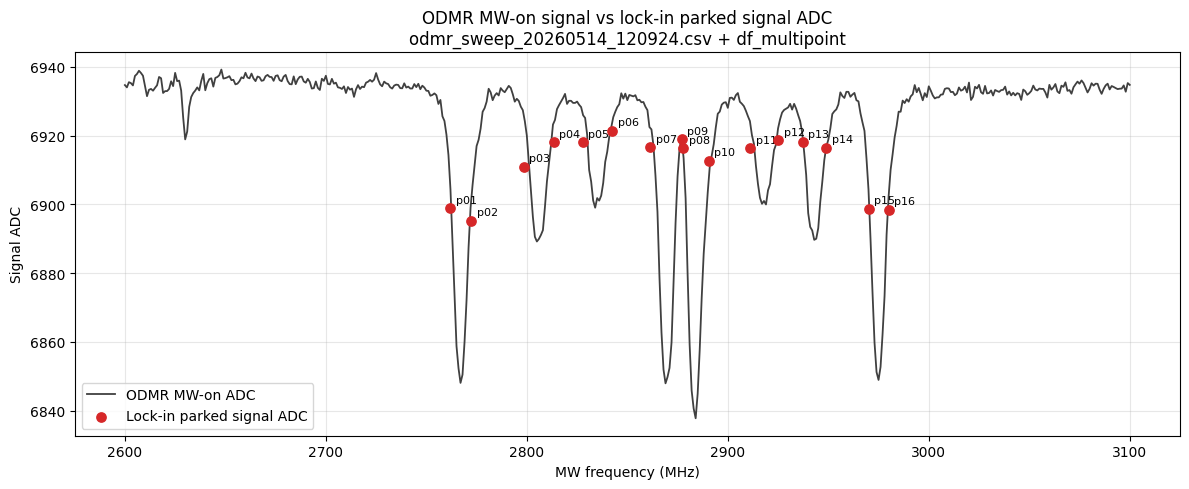

In [9]:
# Step 2 — Acquire all 16 parked frequencies in ONE FPGA program upload.
# Avoids the ~5 s overhead of building 16 separate LockinODMR programs.
#
# DEFENSIVE GUARD (added to prevent the 01_basic 5-minute pathology):
#   The MultipointLockinODMR program is built ONCE before the batch loop.
#   The old 8-peak cell built qd.LockinODMR(cfg) 17× per batch — each build is
#   a ~300-500 ms FPGA upload, so 17 × 5 batches ≈ 25-50 seconds just for
#   uploads. This cell builds the program exactly once; assertions below
#   make it impossible to slip back into the bad pattern.
import sys
from copy import copy
from pathlib import Path
from time import perf_counter, time
import numpy as np
import pandas as pd
from IPython.display import FileLink, display

# notebook_modules/ is already on sys.path via the project_root_setup cell,
# so multipoint_lockin_program is directly importable.
import importlib
import multipoint_lockin_program
multipoint_lockin_program = importlib.reload(multipoint_lockin_program)
from multipoint_lockin_program import MultipointLockinODMR

# --- Acquisition parameters ---
MULTIPOINT_REPS_PER_BATCH = 10
MULTIPOINT_N_BATCHES = 1
MULTIPOINT_OFF_RESONANCE_MHZ = 2700.0     # off-resonance reference frequency
# Delay between signal and off-resonance reference shots. Kept explicit so the
# timing is easy to tune independently from the reference method.
MULTIPOINT_RELAX_DELAY_TREG = 1000
MULTIPOINT_DATA_CSV = PROJECT_ROOT / "data" / "lockin_multipoint" / "multipoint_lockin_collected.csv"
MULTIPOINT_DATA_CSV.parent.mkdir(parents=True, exist_ok=True)

# --- Build the multipoint config ---
cfg = copy(default_config)
cfg.multipoint_freqs_mhz = list(MULTIPOINT_FREQS_MHZ)
cfg.odmr_reference_offres_mhz = MULTIPOINT_OFF_RESONANCE_MHZ
cfg.relax_delay_treg = int(MULTIPOINT_RELAX_DELAY_TREG)
# QickSweep needs >= 2 points; we add a trivial 2-point zero-span outer sweep.
cfg.mw_start_fMHz = float(MULTIPOINT_FREQS_MHZ[0])
cfg.mw_end_fMHz = float(MULTIPOINT_FREQS_MHZ[0])
cfg.nsweep_points = 1
cfg.reps = int(MULTIPOINT_REPS_PER_BATCH)
cfg.pre_init = getattr(default_config, "pre_init", True) # Change this to True for default 

# --- Build ONE program (handles all 16 frequencies internally) ---
t_build_start = perf_counter()
prog = MultipointLockinODMR(cfg)
_build_seconds = perf_counter() - t_build_start
_predicted_ms_per_batch = prog.total_time() * 1e3
print(f"Built single MultipointLockinODMR program for {len(MULTIPOINT_FREQS_MHZ)} frequencies in {_build_seconds:.2f} s")
print(f"Predicted time per batch: {_predicted_ms_per_batch:.0f} ms ({prog.time_per_rep()*1e3:.1f} ms/rep × {cfg.reps} reps)")

# --- Collect N batches, each batch = one acquire = one full sweep over all 16 freqs ---
# DEFENSIVE GUARD: prog is built ABOVE this loop. Inside the loop, prog.acquire()
# only triggers the existing FPGA program — no rebuild, no upload. To verify, the
# old-style bad pattern was:
#     for batch in range(N):
#         prog = MultipointLockinODMR(cfg)   # ← BAD: rebuild every batch
#         d = prog.acquire(...)
# The current loop simply reads d_batch from the already-built prog.
_first_batch_dt = None
rows = []
t0 = perf_counter()
for batch in range(int(MULTIPOINT_N_BATCHES)):
    t_acq_start = perf_counter()
    d_batch = prog.acquire(progress=False)
    acq_dt = perf_counter() - t_acq_start
    if _first_batch_dt is None:
        _first_batch_dt = acq_dt

    row = {
        "batch": batch,
        "time_s": perf_counter() - t0,
        "timestamp_epoch_s": time(),
        "acq_seconds": acq_dt,
    }
    # Record one column per parked frequency, in point_index order.
    for k, (freq_mhz, sig, ref) in enumerate(zip(d_batch.frequencies_mhz, d_batch.signal, d_batch.reference)):
        row[f"peak_{k+1:02d}"] = float(sig)
        row[f"peak_{k+1:02d}_ref"] = float(ref)
        row[f"peak_{k+1:02d}_freq_mhz"] = float(freq_mhz)
    rows.append(row)
    print(f"batch {batch+1}/{int(MULTIPOINT_N_BATCHES)}: acquired in {acq_dt*1000:.0f} ms "
          f"(predicted ~{_predicted_ms_per_batch:.0f} ms)")

df_multipoint = pd.DataFrame(rows)
df_multipoint.to_csv(MULTIPOINT_DATA_CSV, index=False)
print(f"\nSaved {len(df_multipoint)} batches to {MULTIPOINT_DATA_CSV}")

# Sanity-check the runtime: if the first batch took dramatically longer than
# predicted, surface it. Acceptable factor is ~5x because the very first
# acquire() includes any one-time board warm-up.
if _first_batch_dt * 1000 > _predicted_ms_per_batch * 5:
    print(f"⚠ First batch took {_first_batch_dt*1000:.0f} ms vs predicted "
          f"{_predicted_ms_per_batch:.0f} ms. If this persists across multiple cell "
          f"runs, network/board state is the likely cause.")

display(df_multipoint)
display(FileLink(str(MULTIPOINT_DATA_CSV)))


# --- Files ---
# Use the same ODMR that generated the parked plan; otherwise latest saved ODMR.
if "ODMR_CSV_FOR_PLAN" in globals() and Path(ODMR_CSV_FOR_PLAN).exists():
    ODMR_CSV = Path(ODMR_CSV_FOR_PLAN)
else:
    odmr_dir = PROJECT_ROOT / "data" / "odmr_sweeps"
    ODMR_CSV = sorted(odmr_dir.glob("odmr_sweep_*.csv"))[-1]

print(f"Using ODMR overlay source: {ODMR_CSV}")

# Use the just-collected multipoint DataFrame if it exists; otherwise load the saved one
if "df_multipoint" in globals():
    df_lockin = df_multipoint.copy()
    lockin_label = "df_multipoint"
else:
    LOCKIN_CSV = Path("/Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/multipoint_lockin_collected.csv")
    df_lockin = pd.read_csv(LOCKIN_CSV)
    lockin_label = LOCKIN_CSV.name

df_odmr = pd.read_csv(ODMR_CSV)

# --- ODMR raw MW-on ADC ---
odmr_freq = df_odmr["frequency_MHz"].to_numpy(dtype=float)
odmr_signal_adc = df_odmr["photoluminescence_mw_on_ADC"].to_numpy(dtype=float)

# --- Lock-in parked signal ADC, first batch/row ---
row = df_lockin.iloc[0]

peak_freqs = []
peak_signals = []

k = 1
while f"peak_{k:02d}_freq_mhz" in df_lockin.columns:
    peak_freqs.append(float(row[f"peak_{k:02d}_freq_mhz"]))
    peak_signals.append(float(row[f"peak_{k:02d}"]))
    k += 1

peak_freqs = np.array(peak_freqs)
peak_signals = np.array(peak_signals)

# --- Plot ---
plt.figure(figsize=(12, 5))
plt.plot(
    odmr_freq,
    odmr_signal_adc,
    color="0.25",
    lw=1.3,
    label="ODMR MW-on ADC"
)

plt.scatter(
    peak_freqs,
    peak_signals,
    color="tab:red",
    s=45,
    zorder=5,
    label="Lock-in parked signal ADC"
)

for i, (f, s) in enumerate(zip(peak_freqs, peak_signals), start=1):
    plt.annotate(f"p{i:02d}", (f, s), xytext=(4, 4), textcoords="offset points", fontsize=8)

plt.xlabel("MW frequency (MHz)")
plt.ylabel("Signal ADC")
plt.title(f"ODMR MW-on signal vs lock-in parked signal ADC\n{ODMR_CSV.name} + {lockin_label}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Convert lock-in signal differences to new peak frequencies

In [10]:
# Step 2.5 — Two-point lock-in calibration: signal differences → new peak frequencies.
# Inputs from previous cells:
#   freqs_mhz, measured, transition_centers   (from lockin_plan: reference ODMR sweep)
#   parked_plan, BIAS_MT                      (from lockin_plan)
#   df_multipoint, MULTIPOINT_DATA_CSV        (from lockin_acquire)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# nv_toolkit was added to sys.path in lockin_plan; use the same import path here.
from nv_toolkit.intensity_tracking import build_blockwise_calibrations
from nv_toolkit.two_point import estimate_delta_f_mhz, normalised_signal_from_counts

# --- 1. Build per-block parked-frequency calibrations from the reference ODMR ---
if BIAS_MT is None:
    raise RuntimeError(
        "BIAS_MT is None — bias estimate failed in lockin_plan. "
        "Two-point calibration needs B_bias to compute df/dB."
    )

# Flatten parked_plan into the (parked_freqs, block_indices, point_in_block) triple
# that build_blockwise_calibrations expects. point_in_block uses 0=minus, 1=plus.
_parked_freqs = []
_block_indices = []
_point_in_block = []
for i, entry in enumerate(parked_plan, start=1):
    _parked_freqs.append(float(entry.frequency_minus_mhz))
    _block_indices.append(i)
    _point_in_block.append(0)
    _parked_freqs.append(float(entry.frequency_plus_mhz))
    _block_indices.append(i)
    _point_in_block.append(1)

calibrations = build_blockwise_calibrations(
    reference_freqs_mhz=np.asarray(freqs_mhz, dtype=float),
    reference_spectrum=np.asarray(measured, dtype=float),
    parked_freqs_mhz=np.asarray(_parked_freqs, dtype=float),
    block_indices=np.asarray(_block_indices, dtype=int),
    point_in_block=np.asarray(_point_in_block, dtype=int),
    B_bias_mT=np.asarray(BIAS_MT, dtype=float),
)
assert len(calibrations) == len(parked_plan), \
    f"Expected {len(parked_plan)} calibrations, got {len(calibrations)}"

# --- 2. For each acquired batch, compute Δf and the new peak frequency per block ---
results_rows = []
for _, batch in df_multipoint.iterrows():
    for block_idx in sorted(calibrations):
        calib = calibrations[block_idx]
        i_minus = 2 * (block_idx - 1) + 1   # peak_01, peak_03, …  (left flank)
        i_plus  = 2 * (block_idx - 1) + 2   # peak_02, peak_04, …  (right flank)

        # Normalize raw ADC counts → same scale as the calibration's baselines.
        s_minus_n = normalised_signal_from_counts(
            float(batch[f"peak_{i_minus:02d}"]),
            float(batch[f"peak_{i_minus:02d}_ref"]),
        )
        s_plus_n = normalised_signal_from_counts(
            float(batch[f"peak_{i_plus:02d}"]),
            float(batch[f"peak_{i_plus:02d}_ref"]),
        )

        delta_f_mhz = estimate_delta_f_mhz(s_minus_n, s_plus_n, calib)
        sensitivity = calib.sensitivity_norm_mhz_per_mT
        delta_B_proj_mT = float(delta_f_mhz / sensitivity) if sensitivity > 0 else float("nan")

        results_rows.append({
            "batch":               int(batch["batch"]),
            "block":               int(block_idx),
            "f0_old_mhz":          float(calib.resonance_frequency_mhz),
            "f_minus_mhz":         float(calib.f_minus_mhz),
            "f_plus_mhz":          float(calib.f_plus_mhz),
            "slope_minus_per_mhz": float(calib.slope_minus_per_mhz),
            "slope_plus_per_mhz":  float(calib.slope_plus_per_mhz),
            "baseline_minus":      float(calib.baseline_minus),
            "baseline_plus":       float(calib.baseline_plus),
            "S_minus_norm":        float(s_minus_n),
            "S_plus_norm":         float(s_plus_n),
            "current_diff":        float(s_plus_n - s_minus_n),
            "baseline_diff":       float(calib.baseline_plus - calib.baseline_minus),
            "delta_d":             float((s_plus_n - s_minus_n) - (calib.baseline_plus - calib.baseline_minus)),
            "delta_f_mhz":         float(delta_f_mhz),
            "f_new_mhz":           float(calib.resonance_frequency_mhz + delta_f_mhz),
            "delta_B_proj_mT":     delta_B_proj_mT,
            "delta_B_proj_uT":     delta_B_proj_mT * 1000.0,
            "sensitivity_mhz_per_mT": float(sensitivity),
        })

df_peak_inference = pd.DataFrame(results_rows)

# --- 3. Save alongside the wide-format collected CSV ---
PEAK_INFERENCE_CSV = MULTIPOINT_DATA_CSV.with_name("multipoint_lockin_peak_inference.csv")
df_peak_inference.to_csv(PEAK_INFERENCE_CSV, index=False)
print(f"Wrote per-transition Δf and new peak frequencies to:\n  {PEAK_INFERENCE_CSV}\n")

# Compact summary table for the latest batch only
_summary_cols = ["block", "f0_old_mhz", "delta_f_mhz", "f_new_mhz",
                 "delta_B_proj_uT", "current_diff", "baseline_diff", "delta_d"]
print(f"Latest batch (#{int(df_multipoint['batch'].iloc[-1])}) — per-transition new peak frequencies:")
display(df_peak_inference.loc[df_peak_inference["batch"] == int(df_multipoint["batch"].iloc[-1]),
                              _summary_cols]
                         .reset_index(drop=True))

# Sanity invariants
_first = df_peak_inference.loc[df_peak_inference["batch"] == int(df_multipoint["batch"].iloc[0])]
_max_first_delta_f = float(_first["delta_f_mhz"].abs().max())
print(f"\nSanity check — first batch max |Δf|: {_max_first_delta_f:.4f} MHz "
      f"({'looks like calibration is consistent' if _max_first_delta_f < 1.0 else 'WARNING: may indicate drift or normalization mismatch'})")
_signs_ok = ((df_peak_inference["slope_minus_per_mhz"] < 0) &
             (df_peak_inference["slope_plus_per_mhz"]  > 0)).all()
print(f"Slope-sign invariant (m₋<0 < m₊>0) holds for every block: {_signs_ok}")

Wrote per-transition Δf and new peak frequencies to:
  /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/multipoint_lockin_peak_inference.csv

Latest batch (#0) — per-transition new peak frequencies:


,block,f0_old_mhz,delta_f_mhz,f_new_mhz,delta_B_proj_uT,current_diff,baseline_diff,delta_d
0,1,2767.256691,-0.005086,2767.251605,-0.181261,-0.000469,-0.000484,0.000015
1,2,2805.427203,-0.150696,2805.276507,-5.356336,-0.000163,-0.000296,0.000133
2,3,2833.960874,-1.174181,2832.786693,-41.717083,0.000353,-0.000352,0.000705
3,4,2869.517982,2.220603,2871.738585,82.907941,0.000314,-0.001067,0.001381
4,5,2884.012957,-1.183498,2882.829459,-44.046181,-0.000157,-0.001638,0.001481
5,6,2917.792373,0.293657,2918.086031,10.429311,-0.000451,-0.000175,-0.000277
6,7,2943.207290,0.059219,2943.266508,2.104610,-0.000470,-0.000403,-0.000067
7,8,2975.060075,0.013776,2975.073852,0.490959,-0.000226,-0.000183,-0.000042



Sanity check — first batch max |Δf|: 2.2206 MHz (WARNING: may indicate drift or normalization mismatch)
Slope-sign invariant (m₋<0 < m₊>0) holds for every block: False


## Reconstruct B-field vectors from collected parked-frequency data

In [11]:
# Step 3 — Reconstruct B-field vectors from collected parked-frequency data.
# Uses nv_toolkit's _compute_live_snapshot (same algorithm as `mag-operator reconstruct`).
import csv
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import FileLink, display

from nv_toolkit.tui import OperatorConfig, _compute_live_snapshot

# Inputs (set by the cells above)
_full_scan_path = ODMR_CSV_FOR_PLAN
_plan_csv_path = PARKED_PLAN_CSV
_collected_csv_path = MULTIPOINT_DATA_CSV

# The wide format expected by _compute_live_snapshot needs:
#   time_s + 16 intensity columns in point_index order (no _ref/_freq_mhz extras).
# We rewrite our richer collected CSV into a clean wide format here.
# Each peak column is normalised by its per-batch off-resonance reference shot
# so the values match the calibration's normalised scale (calibration is built
# from `measured = mw_on / np.median(mw_on)`); without this, raw ADC counts
# fed against a normalised calibration yield ~10^5 µT garbage.
_wide_for_recon = _collected_csv_path.with_name(_collected_csv_path.stem + "_wide.csv")
_clean_df = pd.DataFrame({"time_s": df_multipoint["time_s"]})
for k in range(len(MULTIPOINT_FREQS_MHZ)):
    col = f"peak_{k+1:02d}"
    _clean_df[col] = df_multipoint[col] / df_multipoint[f"{col}_ref"]
_clean_df.to_csv(_wide_for_recon, index=False)

# Reuse the bias estimate from the plan cell (or recompute here).
_bias_mT = BIAS_MT if BIAS_MT is not None else np.zeros(3, dtype=float)

config = OperatorConfig(
    full_scan_path=_full_scan_path,
    parked_data_path=_wide_for_recon,
    parked_format="wide",
    bias_field_mT=np.asarray(_bias_mT, dtype=float),
    reference_freqs_mhz=np.asarray(freqs_mhz, dtype=float),
    reference_spectrum=np.asarray(measured, dtype=float),
    transition_centers_mhz=np.asarray(transition_centers, dtype=float),
    parked_plan=tuple(parked_plan),
    plan_csv_path=_plan_csv_path,
    wide_template_path=_plan_csv_path.with_name("parked_template_wide.csv"),
    long_template_path=_plan_csv_path.with_name("parked_template_long.csv"),
    poll_interval_s=0.0,
)
snapshot = _compute_live_snapshot(config)
if snapshot.status == "error":
    raise ValueError(snapshot.message)

# Output CSVs
VECTOR_CSV = _collected_csv_path.with_name("reconstructed_vector_rows.csv")
PROJECTION_CSV = _collected_csv_path.with_name("reconstructed_projection_rows.csv")

def _write_rows(path, rows):
    if not rows:
        path.write_text("")
        return
    fieldnames = []
    for r in rows:
        for key in r:
            if key not in fieldnames:
                fieldnames.append(str(key))
    with path.open("w", newline="") as h:
        writer = csv.DictWriter(h, fieldnames=fieldnames)
        writer.writeheader()
        for r in rows:
            writer.writerow({k: r.get(k, "") for k in fieldnames})

_write_rows(VECTOR_CSV, snapshot.vector_rows)
_write_rows(PROJECTION_CSV, snapshot.projection_rows)

print(f"status: {snapshot.status}")
print(f"samples: {snapshot.sample_count}  rank-ok: {snapshot.ok_count}")
print(f"vector CSV:     {VECTOR_CSV}")
print(f"projection CSV: {PROJECTION_CSV}")

if snapshot.vector_rows:
    display(pd.DataFrame(snapshot.vector_rows))
if snapshot.projection_rows:
    print("Projection rows (one per block per timestamp):")
    display(pd.DataFrame(snapshot.projection_rows))

display(FileLink(str(VECTOR_CSV)))
display(FileLink(str(PROJECTION_CSV)))




status: ok
samples: 1  rank-ok: 1
vector CSV:     /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/reconstructed_vector_rows.csv
projection CSV: /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/reconstructed_projection_rows.csv


,save_id,timestamp_epoch_s,n_channels,rank,condition_number,residual_norm_uT,delta_Bx_uT,delta_By_uT,delta_Bz_uT,status
0,000000,0.112848,8,3,9.735704,90.378629,18.580396,-6.770424,25.21036,ok


Projection rows (one per block per timestamp):


,save_id,timestamp_epoch_s,block_index,frequency_minus_mhz,frequency_plus_mhz,intensity_minus,intensity_plus,delta_B_projection_mT,delta_B_projection_uT,delta_Bx_uT,delta_By_uT,delta_Bz_uT,measurement_axis_x,measurement_axis_y,measurement_axis_z,sensitivity_norm_mhz_per_mT,slope_denom_abs,transition_index
0,000000,0.112848,1,2761.973177,2772.330533,0.999652,0.999183,-0.000181,-0.181261,0.152685,0.003167,-0.097635,-0.842352,-0.017472,0.538644,28.059888,0.002966,0
1,000000,0.112848,2,2798.513285,2813.355335,0.999977,0.999814,-0.005356,-5.356336,-0.331289,-4.575301,-2.765357,0.061850,0.854185,0.516278,28.134082,0.000883,1
2,000000,0.112848,3,2827.902817,2842.440946,1.000102,1.000456,-0.041717,-41.717083,-2.546036,36.033770,-20.866244,0.061031,-0.863765,0.500185,28.146294,0.000601,2
3,000000,0.112848,4,2861.343352,2877.767432,1.000017,1.000331,0.082908,82.907941,72.547865,-1.341500,40.109030,0.875041,-0.016181,0.483778,26.783960,0.000622,3
4,000000,0.112848,5,2877.088880,2890.551429,1.000137,0.999980,-0.044046,-44.046181,32.192039,0.873511,30.049554,-0.730870,-0.019832,-0.682228,26.869488,0.001251,4
5,000000,0.112848,6,2911.240464,2924.984576,1.000108,0.999657,0.010429,10.429311,0.650069,7.907294,-6.769242,0.062331,0.758180,-0.649059,28.156940,0.000942,5
6,000000,0.112848,7,2937.185655,2949.104252,1.000717,1.000247,0.002105,2.104610,0.129887,-1.623886,-1.332480,0.061715,-0.771586,-0.633125,28.137587,0.001125,6
7,000000,0.112848,8,2970.054140,2980.001923,0.999630,0.999405,0.000491,0.490959,0.387485,-0.008394,-0.301373,0.789241,-0.017098,-0.613845,28.060057,0.003066,7


/Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/reconstructed_vector_rows.csv

/Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/reconstructed_projection_rows.csv

## Live (continuous) two-point lock-in time series

The cells above run a **single batch** of `MULTIPOINT_REPS_PER_BATCH` reps and stop. For a real-time magnetometer we want to keep acquiring batch after batch and stream the per-block Δf to disk (and optionally to a live plot).

The cell below also Δf-converts each batch on the fly using the same `TwoPointCalibration` objects from the cell above, so the saved CSV has both the raw `peak_NN`/`peak_NN_ref` columns (toolkit-compatible wide format) **and** the per-block `delta_f_mhz_b<NN>` and `f_new_mhz_b<NN>` columns. Stop with the Interrupt button (■) or by setting `LIVE_DURATION_SEC`.


Built LIVE program (pre_init=False) for 16 freqs, 10 reps/batch, predicted ~69 ms/batch FPGA work
Watchdog: will warn if any batch exceeds 208 ms (predicted × 3.0).
Priming spin polarization (one acquire with pre_init=True)…
Priming done. Entering live loop.

Spike rejection: enabled=True, window=7, k_sigma=4, warmup=1, sigma_floor=1.5, baseline=/Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/multipoint_lockin_collected.csv



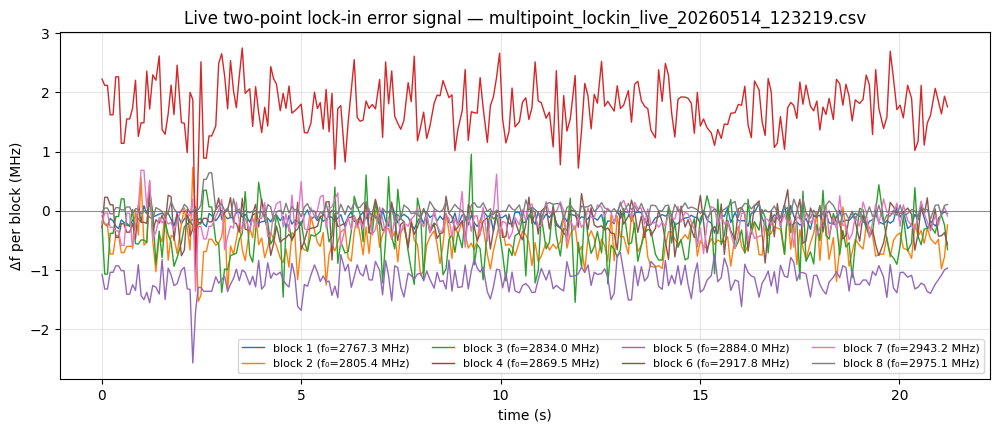

Live stopped by user — 265 batches collected.

Live run finished: 266 batches in 21.3 s (12.5 Hz update rate)
Saved to: /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/multipoint_lockin_live_20260514_123219.csv


/Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/multipoint_lockin_live_20260514_123219.csv


Per-batch timing (ms):  predicted ~69  actual median=12, p95=14, max=18
Watchdog never fired — runtime is consistent with prediction. ✅

Spike rejection: 48 signal-channel rejections, 24 reference-channel rejections (1.13% of signal cells, 0.56% of reference cells).


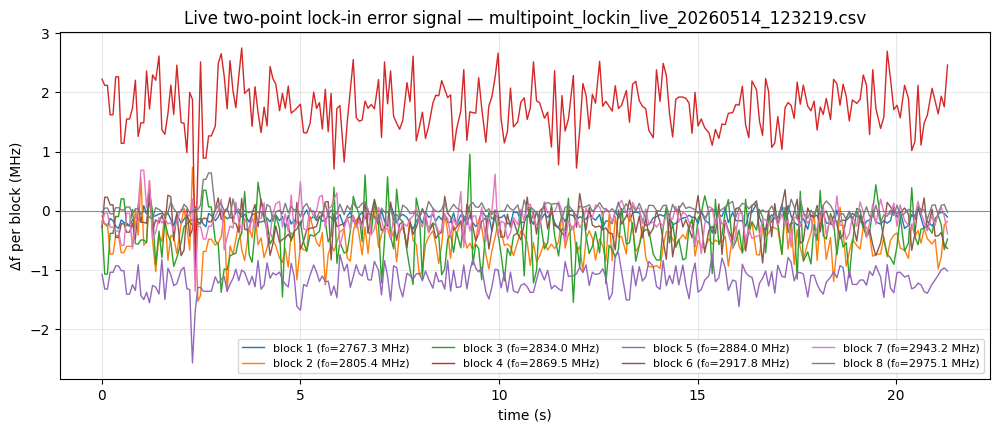

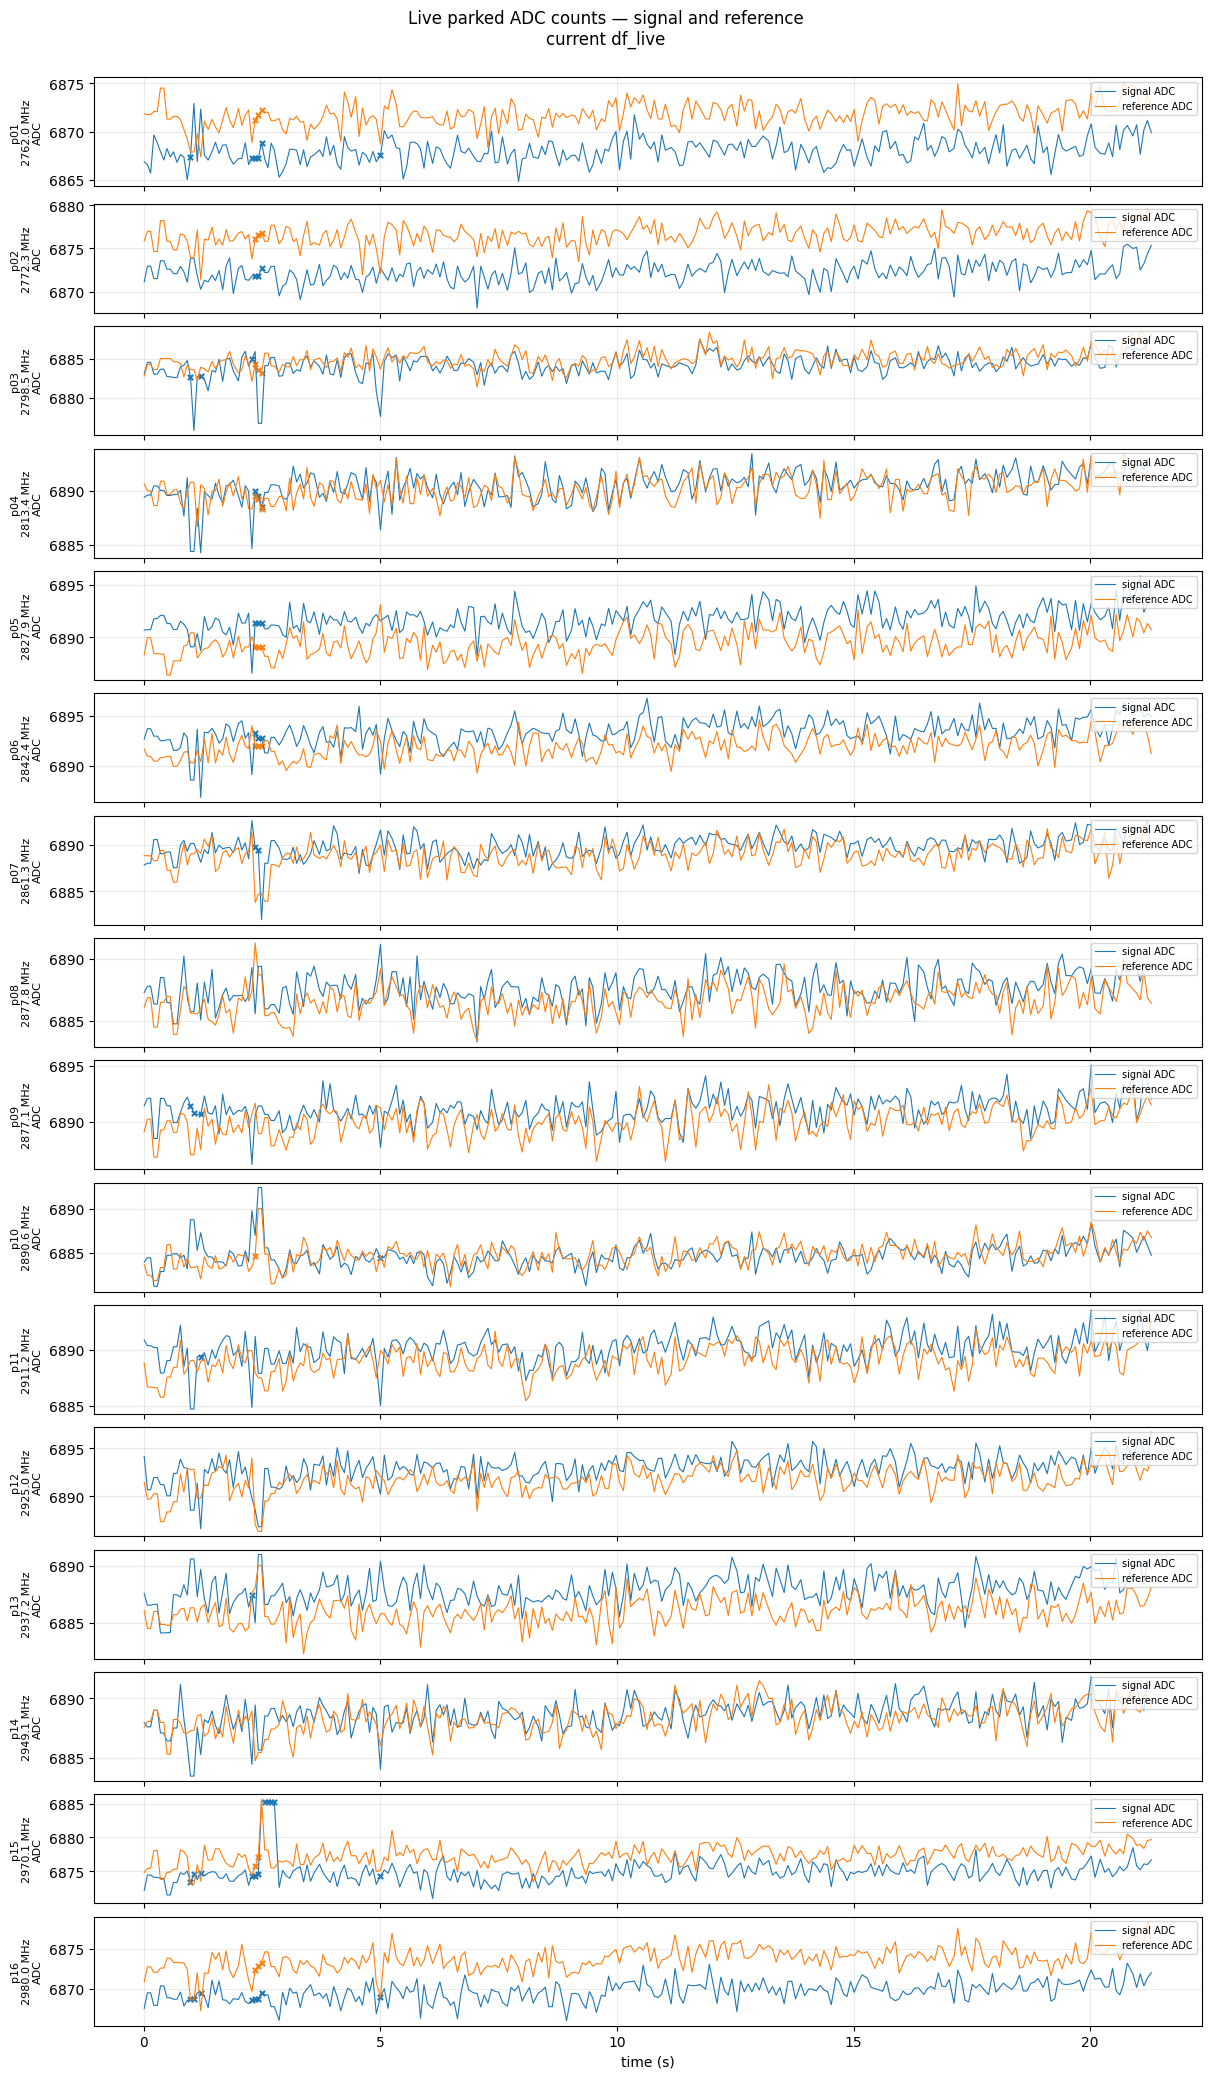

In [39]:
# Step 4 — Live (continuous) two-point lock-in time series.
# Reuses the program + calibrations built above. Fixes the per-batch peaking
# transient by priming pre_init=True ONCE, then running with pre_init=False.
#
# DEFENSIVE GUARDS (added to prevent the 01_basic 5-minute pathology):
#   - assert pre_init=False on the live program (peaking guard)
#   - assert the program is built BEFORE the loop (runtime guard)
#   - watchdog that warns if any batch takes > 3x predicted time
#   - end-of-run summary with median/p95 batch times so drift is visible
#
# SPIKE REJECTION (added 2026-05-13): causal Hampel filter on the raw ADC
# vectors (signal and reference, 16 channels each) inside the live loop.
# Rejects single-batch ADC glitches and replaces them with the rolling
# per-channel median. See notebook_modules/spike_rejection.py.
import sys
from copy import copy
from pathlib import Path
from time import perf_counter, time as _wallclock
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import FileLink, display

# nv_toolkit was already imported by lockin_plan; reuse the same calibrations
# computed by lockin_to_peak_frequency. If that cell wasn't run, raise.
if "calibrations" not in globals() or len(calibrations) == 0:
    raise RuntimeError(
        "Run the 'lockin_to_peak_frequency' cell once before live mode — "
        "it builds the per-block TwoPointCalibration objects this cell reuses."
    )
from nv_toolkit.two_point import estimate_delta_f_mhz, normalised_signal_from_counts

# notebook_modules/ is already on sys.path via the project_root_setup cell,
# so multipoint_lockin_program is directly importable.
import importlib
import multipoint_lockin_program
multipoint_lockin_program = importlib.reload(multipoint_lockin_program)
from multipoint_lockin_program import MultipointLockinODMR

import spike_rejection
spike_rejection = importlib.reload(spike_rejection)
from spike_rejection import HampelDespiker

# --- Live-mode parameters ---
LIVE_REPS_PER_BATCH       = 10          # reps inside each acquire() call (smaller = faster updates, noisier per batch)
LIVE_DURATION_SEC         = 60.0        # set None to run until ■ Interrupt
LIVE_PLOT_REFRESH_EVERY   = 1           # redraw plot every N batches (1 = every batch)
LIVE_OFF_RESONANCE_MHZ    = MULTIPOINT_OFF_RESONANCE_MHZ if "MULTIPOINT_OFF_RESONANCE_MHZ" in globals() else 2700.0
# Long relax_delay between signal and reference (laser repolarization time).
# Reuses the value from lockin_acquire if it was set, otherwise defaults
# to 500 000 treg (~500 µs).
LIVE_RELAX_DELAY_TREG     = 1000
LIVE_WATCHDOG_FACTOR      = 3.0         # warn if a batch exceeds predicted_time * factor

# --- Spike rejection parameters (causal Hampel filter on raw ADC) ---
LIVE_DESPIKE_ENABLED   = True   # set False to bypass and store raw ADC unchanged
LIVE_DESPIKE_WINDOW    = 7      # trailing samples kept per channel
LIVE_DESPIKE_K_SIGMA   = 4    # rejection threshold in units of MAD-sigma, original = 4.0
LIVE_DESPIKE_WARMUP    = 1      # batches before rejection becomes active, original = 4
LIVE_DESPIKE_SIGMA_FLOOR = 1.5  # minimum sigma estimate (ADC counts), matches observed baseline noise ~1.1 ADC

_run_stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
LIVE_CSV = PROJECT_ROOT / "data" / "lockin_multipoint" / f"multipoint_lockin_live_{_run_stamp}.csv"
LIVE_CSV.parent.mkdir(parents=True, exist_ok=True)

# --- Build the LIVE program with pre_init = False (no per-batch repolarization) ---
cfg_live = copy(default_config)
cfg_live.multipoint_freqs_mhz       = list(MULTIPOINT_FREQS_MHZ)
cfg_live.odmr_reference_offres_mhz  = LIVE_OFF_RESONANCE_MHZ
cfg_live.relax_delay_treg           = int(LIVE_RELAX_DELAY_TREG)
cfg_live.mw_start_fMHz              = float(MULTIPOINT_FREQS_MHZ[0])
cfg_live.mw_end_fMHz                = float(MULTIPOINT_FREQS_MHZ[0])
cfg_live.nsweep_points              = 1
cfg_live.reps                       = int(LIVE_REPS_PER_BATCH)
cfg_live.pre_init                   = False     # ← fix the peaking batching issue

# DEFENSIVE GUARD #1 (peaking): pre_init must be False on the live program.
# If something later accidentally sets it True, this assertion catches it before
# the FPGA program is built.
assert cfg_live.pre_init is False, (
    "Live mode requires pre_init=False to prevent per-batch peaking. "
    "An MW polarization pulse at start_freq before the body loop perturbs "
    "spins toward |±1⟩ at every batch boundary; with always-on laser the "
    "in-body readout windows then have to re-polarize, producing a transient."
)

prog_live = MultipointLockinODMR(cfg_live)
_predicted_ms_per_batch = prog_live.total_time() * 1e3
print(f"Built LIVE program (pre_init=False) for {len(MULTIPOINT_FREQS_MHZ)} freqs, "
      f"{cfg_live.reps} reps/batch, predicted ~{_predicted_ms_per_batch:.0f} ms/batch FPGA work")
print(f"Watchdog: will warn if any batch exceeds {_predicted_ms_per_batch * LIVE_WATCHDOG_FACTOR:.0f} ms "
      f"(predicted × {LIVE_WATCHDOG_FACTOR}).")

# --- One-shot priming acquire with pre_init=True (results discarded) ---
# In an always-on-laser setup this is mostly defensive scaffolding — the laser
# is already polarizing the NVs continuously. Kept in case the laser is ever
# gated again, and so the very first prog_live.acquire() doesn't fight the FPGA's
# initial generator state.
cfg_prime = copy(cfg_live)
cfg_prime.pre_init = True
prog_prime = MultipointLockinODMR(cfg_prime)
print("Priming spin polarization (one acquire with pre_init=True)…")
_ = prog_prime.acquire(progress=False)
del prog_prime, cfg_prime
print("Priming done. Entering live loop.\n")

# --- Spike-rejection setup: load single-batch baseline (Cell 12 output) as warm-up fallback ---
_sig_baseline = None
_ref_baseline = None
_baseline_src = "(none)"
if LIVE_DESPIKE_ENABLED:
    try:
        _bl_row = pd.read_csv(MULTIPOINT_DATA_CSV).iloc[-1]
        _sig_baseline = np.array([float(_bl_row[f"peak_{i:02d}"])     for i in range(1, 17)])
        _ref_baseline = np.array([float(_bl_row[f"peak_{i:02d}_ref"]) for i in range(1, 17)])
        _baseline_src = str(MULTIPOINT_DATA_CSV)
    except Exception as _e:
        print(f"  (despike) no single-batch baseline available ({_e}); warm-up will pass samples through.")
despiker_sig = HampelDespiker(
    n_channels=16,
    window=LIVE_DESPIKE_WINDOW,
    k_sigma=LIVE_DESPIKE_K_SIGMA,
    min_warmup=LIVE_DESPIKE_WARMUP,
    sigma_floor=LIVE_DESPIKE_SIGMA_FLOOR,
    baseline=_sig_baseline,
)
despiker_ref = HampelDespiker(
    n_channels=16,
    window=LIVE_DESPIKE_WINDOW,
    k_sigma=LIVE_DESPIKE_K_SIGMA,
    min_warmup=LIVE_DESPIKE_WARMUP,
    sigma_floor=LIVE_DESPIKE_SIGMA_FLOOR,
    baseline=_ref_baseline,
)
print(f"Spike rejection: enabled={LIVE_DESPIKE_ENABLED}, window={LIVE_DESPIKE_WINDOW}, "
      f"k_sigma={LIVE_DESPIKE_K_SIGMA}, warmup={LIVE_DESPIKE_WARMUP}, "
      f"sigma_floor={LIVE_DESPIKE_SIGMA_FLOOR}, baseline={_baseline_src}\n")

# --- Live plot setup: Δf per block over time ---
n_blocks = len(calibrations)
plt.ion()
fig, ax = plt.subplots(figsize=(12, 4.5))
_lines = {}
_block_keys = sorted(calibrations)
_colors = plt.cm.tab10(np.linspace(0, 1, max(10, n_blocks)))
for i, k in enumerate(_block_keys):
    line, = ax.plot([], [], "-", color=_colors[i % len(_colors)], lw=1.0,
                    label=f"block {k} (f₀={calibrations[k].resonance_frequency_mhz:.1f} MHz)")
    _lines[k] = line
ax.set_xlabel("time (s)")
ax.set_ylabel("Δf per block (MHz)")
ax.set_title(f"Live two-point lock-in error signal — {LIVE_CSV.name}")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, ncol=4, loc="best")
ax.axhline(0, color="0.4", lw=0.5)
_handle = display(fig, display_id=True)

# --- Live loop ---
# DEFENSIVE GUARD #2 (runtime): the live program is built ABOVE this loop, not
# inside it. The 01_basic 8-peak cell rebuilt the program 17× per batch — that
# pathology is structurally impossible here because the for-loop body uses
# prog_live (already built), never instantiates MultipointLockinODMR.
rows = []
delta_f_history = {k: [] for k in _block_keys}
time_history = []
_acq_seconds_history = []
_n_watchdog_warnings = 0
_n_spike_sig_total = 0
_n_spike_ref_total = 0
t0 = perf_counter()
batch = 0
last_save_t = t0
SAVE_EVERY_SEC = 5.0   # flush CSV every N seconds in case the kernel is killed

try:
    while True:
        t_start = perf_counter() - t0
        d_batch = prog_live.acquire(progress=False)
        t_end   = perf_counter() - t0
        t_mid   = 0.5 * (t_start + t_end)
        acq_dt  = t_end - t_start
        _acq_seconds_history.append(acq_dt)

        # Watchdog — if a batch is taking way too long, surface it immediately.
        if acq_dt * 1000 > _predicted_ms_per_batch * LIVE_WATCHDOG_FACTOR and _n_watchdog_warnings < 5:
            print(f"  ⚠ batch {batch}: acq_seconds={acq_dt*1000:.0f} ms "
                  f"(predicted ~{_predicted_ms_per_batch:.0f} ms). Likely network jitter, "
                  f"not a code bug. Set LIVE_PLOT_REFRESH_EVERY > 1 if it persists.")
            _n_watchdog_warnings += 1
            if _n_watchdog_warnings == 5:
                print("  (further per-batch watchdog warnings suppressed; full timings in summary at end)")

        # ---- Spike rejection on raw ADC (per parked-point) ----
        sig_raw = np.asarray(d_batch.signal,    dtype=float)
        ref_raw = np.asarray(d_batch.reference, dtype=float)
        if LIVE_DESPIKE_ENABLED:
            sig_clean, sig_flags = despiker_sig.update(sig_raw)
            ref_clean, ref_flags = despiker_ref.update(ref_raw)
        else:
            sig_clean, ref_clean = sig_raw, ref_raw
            sig_flags = np.zeros(16, dtype=bool)
            ref_flags = np.zeros(16, dtype=bool)
        _n_spike_sig_total += int(sig_flags.sum())
        _n_spike_ref_total += int(ref_flags.sum())

        row = {
            "batch":             batch,
            "time_s":            t_mid,
            "timestamp_epoch_s": _wallclock(),
            "acq_seconds":       acq_dt,
        }
        # Wide-format peak columns (toolkit-compatible). The values written here
        # are the *despiked* ADC counts, so downstream Δf / B reconstruction
        # automatically uses the cleaned signal. The matching `*_spike_sig` /
        # `*_spike_ref` flags record where a replacement happened.
        for k_idx, (f, s, r) in enumerate(
            zip(d_batch.frequencies_mhz, sig_clean, ref_clean)
        ):
            row[f"peak_{k_idx+1:02d}"]           = float(s)
            row[f"peak_{k_idx+1:02d}_ref"]       = float(r)
            row[f"peak_{k_idx+1:02d}_freq_mhz"]  = float(f)
            row[f"peak_{k_idx+1:02d}_spike_sig"] = bool(sig_flags[k_idx])
            row[f"peak_{k_idx+1:02d}_spike_ref"] = bool(ref_flags[k_idx])

        # On-the-fly Δf per block (uses calibrations from lockin_to_peak_frequency)
        for block_idx in _block_keys:
            calib = calibrations[block_idx]
            i_minus = 2 * (block_idx - 1) + 1
            i_plus  = 2 * (block_idx - 1) + 2
            s_minus_n = normalised_signal_from_counts(row[f"peak_{i_minus:02d}"], row[f"peak_{i_minus:02d}_ref"])
            s_plus_n  = normalised_signal_from_counts(row[f"peak_{i_plus:02d}"],  row[f"peak_{i_plus:02d}_ref"])
            df_mhz = estimate_delta_f_mhz(s_minus_n, s_plus_n, calib)
            row[f"delta_f_mhz_b{block_idx:02d}"] = float(df_mhz)
            row[f"f_new_mhz_b{block_idx:02d}"]   = float(calib.resonance_frequency_mhz + df_mhz)
            delta_f_history[block_idx].append(float(df_mhz))

        time_history.append(t_mid)
        rows.append(row)

        # Live plot refresh
        if batch % LIVE_PLOT_REFRESH_EVERY == 0:
            for k in _block_keys:
                _lines[k].set_data(time_history, delta_f_history[k])
            ax.relim()
            ax.autoscale_view()
            fig.canvas.draw_idle()
            _handle.update(fig)

        # Periodic CSV flush
        if perf_counter() - last_save_t > SAVE_EVERY_SEC:
            pd.DataFrame(rows).to_csv(LIVE_CSV, index=False)
            last_save_t = perf_counter()

        batch += 1
        if LIVE_DURATION_SEC is not None and t_end >= LIVE_DURATION_SEC:
            break
except KeyboardInterrupt:
    print(f"Live stopped by user — {batch} batches collected.")
finally:
    plt.ioff()

# --- Final save + summary ---
df_live = pd.DataFrame(rows)
df_live.to_csv(LIVE_CSV, index=False)

print(f"\nLive run finished: {len(df_live)} batches in {df_live['time_s'].iloc[-1]:.1f} s "
      f"({len(df_live)/df_live['time_s'].iloc[-1]:.1f} Hz update rate)")
print(f"Saved to: {LIVE_CSV}")
display(FileLink(str(LIVE_CSV)))

# Timing diagnostics — median, p95, max — so you can compare against prediction.
_acq_arr = np.asarray(_acq_seconds_history) * 1000.0   # ms
print(f"\nPer-batch timing (ms):  predicted ~{_predicted_ms_per_batch:.0f}  "
      f"actual median={np.median(_acq_arr):.0f}, p95={np.percentile(_acq_arr, 95):.0f}, "
      f"max={_acq_arr.max():.0f}")
if _n_watchdog_warnings > 0:
    print(f"Watchdog fired {_n_watchdog_warnings} time(s) (out of {len(_acq_arr)} batches). "
          f"Spikes are network jitter; the FPGA pulse work is constant.")
else:
    print("Watchdog never fired — runtime is consistent with prediction. ✅")

# Spike-rejection summary
if LIVE_DESPIKE_ENABLED and len(df_live) > 0:
    _n_total_cells = len(df_live) * 16
    print(f"\nSpike rejection: {_n_spike_sig_total} signal-channel rejections, "
          f"{_n_spike_ref_total} reference-channel rejections "
          f"({_n_spike_sig_total / _n_total_cells * 100:.2f}% of signal cells, "
          f"{_n_spike_ref_total / _n_total_cells * 100:.2f}% of reference cells).")


import re

# --- Summary plot: parked ADC signal + reference for all 16 frequencies ---
if "df_live" in globals() and len(df_live) > 0:
    df_live_plot = df_live.copy()
    live_source = "current df_live"
elif "LIVE_CSV" in globals() and Path(LIVE_CSV).exists():
    df_live_plot = pd.read_csv(LIVE_CSV)
    live_source = str(LIVE_CSV)
else:
    raise RuntimeError("No live data found. Run the live acquisition first.")

peak_nums = sorted(
    int(m.group(1))
    for c in df_live_plot.columns
    if (m := re.fullmatch(r"peak_(\d{2})", c))
)

if len(peak_nums) == 0:
    raise RuntimeError("No peak_XX columns found in live data.")

t = df_live_plot["time_s"].to_numpy()

fig_adc, axs = plt.subplots(
    len(peak_nums),
    1,
    figsize=(12, 1.25 * len(peak_nums)),
    sharex=True,
    constrained_layout=True,
)

if len(peak_nums) == 1:
    axs = [axs]

for ax_i, peak_idx in zip(axs, peak_nums):
    sig_col = f"peak_{peak_idx:02d}"
    ref_col = f"peak_{peak_idx:02d}_ref"
    freq_col = f"peak_{peak_idx:02d}_freq_mhz"

    sig = df_live_plot[sig_col].to_numpy(dtype=float)
    ref = df_live_plot[ref_col].to_numpy(dtype=float)

    if freq_col in df_live_plot.columns:
        f_mhz = float(df_live_plot[freq_col].iloc[0])
        ylabel = f"p{peak_idx:02d}\n{f_mhz:.1f} MHz\nADC"
    else:
        ylabel = f"p{peak_idx:02d}\nADC"

    ax_i.plot(t, sig, lw=0.8, label="signal ADC")
    ax_i.plot(t, ref, lw=0.8, label="reference ADC")

    sig_flag_col = f"peak_{peak_idx:02d}_spike_sig"
    ref_flag_col = f"peak_{peak_idx:02d}_spike_ref"

    if sig_flag_col in df_live_plot.columns:
        sig_flags = df_live_plot[sig_flag_col].astype(bool).to_numpy()
        if sig_flags.any():
            ax_i.scatter(t[sig_flags], sig[sig_flags], s=14, marker="x", color="C0")

    if ref_flag_col in df_live_plot.columns:
        ref_flags = df_live_plot[ref_flag_col].astype(bool).to_numpy()
        if ref_flags.any():
            ax_i.scatter(t[ref_flags], ref[ref_flags], s=14, marker="x", color="C1")

    ax_i.set_ylabel(ylabel, fontsize=8)
    ax_i.grid(True, alpha=0.25)
    ax_i.legend(fontsize=7, loc="upper right")

axs[-1].set_xlabel("time (s)")
fig_adc.suptitle(f"Live parked ADC counts — signal and reference\n{live_source}", y=1.032)

plt.show()


## Post-processing the live run

After `lockin_live` finishes (or you reopen the notebook later) the next two cells process the saved CSV:

1. **`lockin_live_post_peak_frequency`** — time-series plot of `Δf` and `f_new` per block over the whole run, plus per-block summary statistics. Reads `delta_f_mhz_b<NN>` and `f_new_mhz_b<NN>` columns that the live cell already wrote.
2. **`lockin_live_post_reconstruct`** — runs `nv_toolkit._compute_live_snapshot` on the wide-format `peak_NN` columns to get the full 3-axis B-field vector time-series, with a multi-panel plot of `ΔBx, ΔBy, ΔBz` vs time. Saves `reconstructed_vector_rows_live.csv` and `reconstructed_projection_rows_live.csv`.

Both cells default to `LIVE_CSV` (the file the live cell just wrote). To re-process an older run, set `LIVE_CSV_OVERRIDE = Path("data/lockin_multipoint/multipoint_lockin_live_<timestamp>.csv")` before running.


Processing live CSV: multipoint_lockin_live_20260514_123219.csv
  266 batches over 21.3 s
  Blocks present: [1, 2, 3, 4, 5, 6, 7, 8]

Per-block summary (live run):


,block,n_samples,delta_f_mean_mhz,delta_f_std_mhz,delta_f_min_mhz,delta_f_max_mhz,f_new_mean_mhz,f_new_std_mhz,delta_B_proj_std_uT
0,1,266,-0.129954,0.088848,-0.377077,0.136491,2767.126737,0.088848,3.166379
1,2,266,-0.514143,0.292424,-1.531479,0.736358,2804.913060,0.292424,10.393957
2,3,266,-0.391501,0.399618,-1.547843,0.956451,2833.569373,0.399618,14.197888
3,4,266,1.748017,0.445502,-1.002633,2.752138,2871.265999,0.445502,16.633171
4,5,266,-1.162614,0.209115,-2.571952,-0.704923,2882.850343,0.209115,7.782636
5,6,266,-0.208974,0.248265,-0.882383,0.371894,2917.583400,0.248265,8.817191
6,7,266,-0.153653,0.235893,-1.358965,0.686679,2943.053637,0.235893,8.383550
7,8,266,0.019816,0.108928,-0.239629,0.640878,2975.079891,0.108928,3.881974


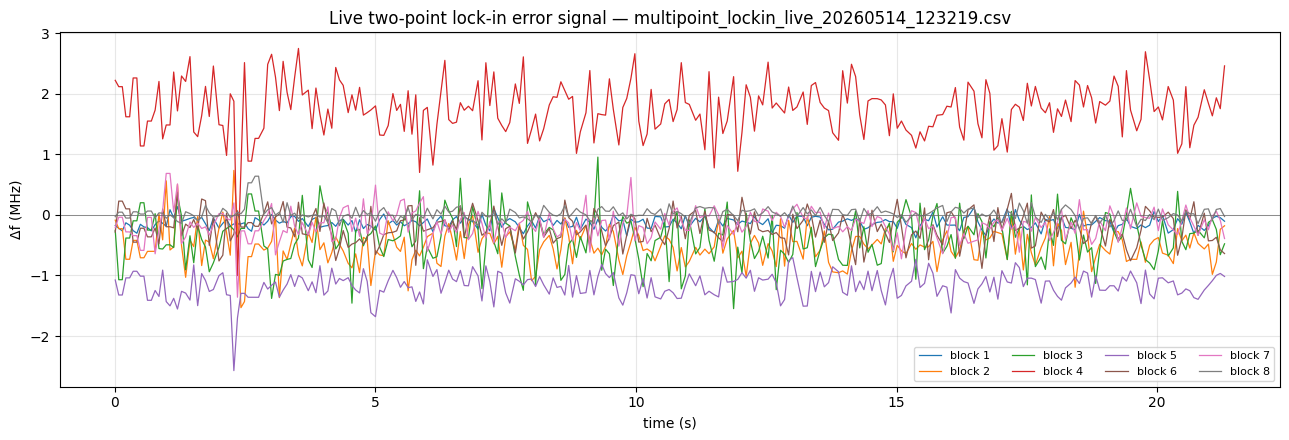

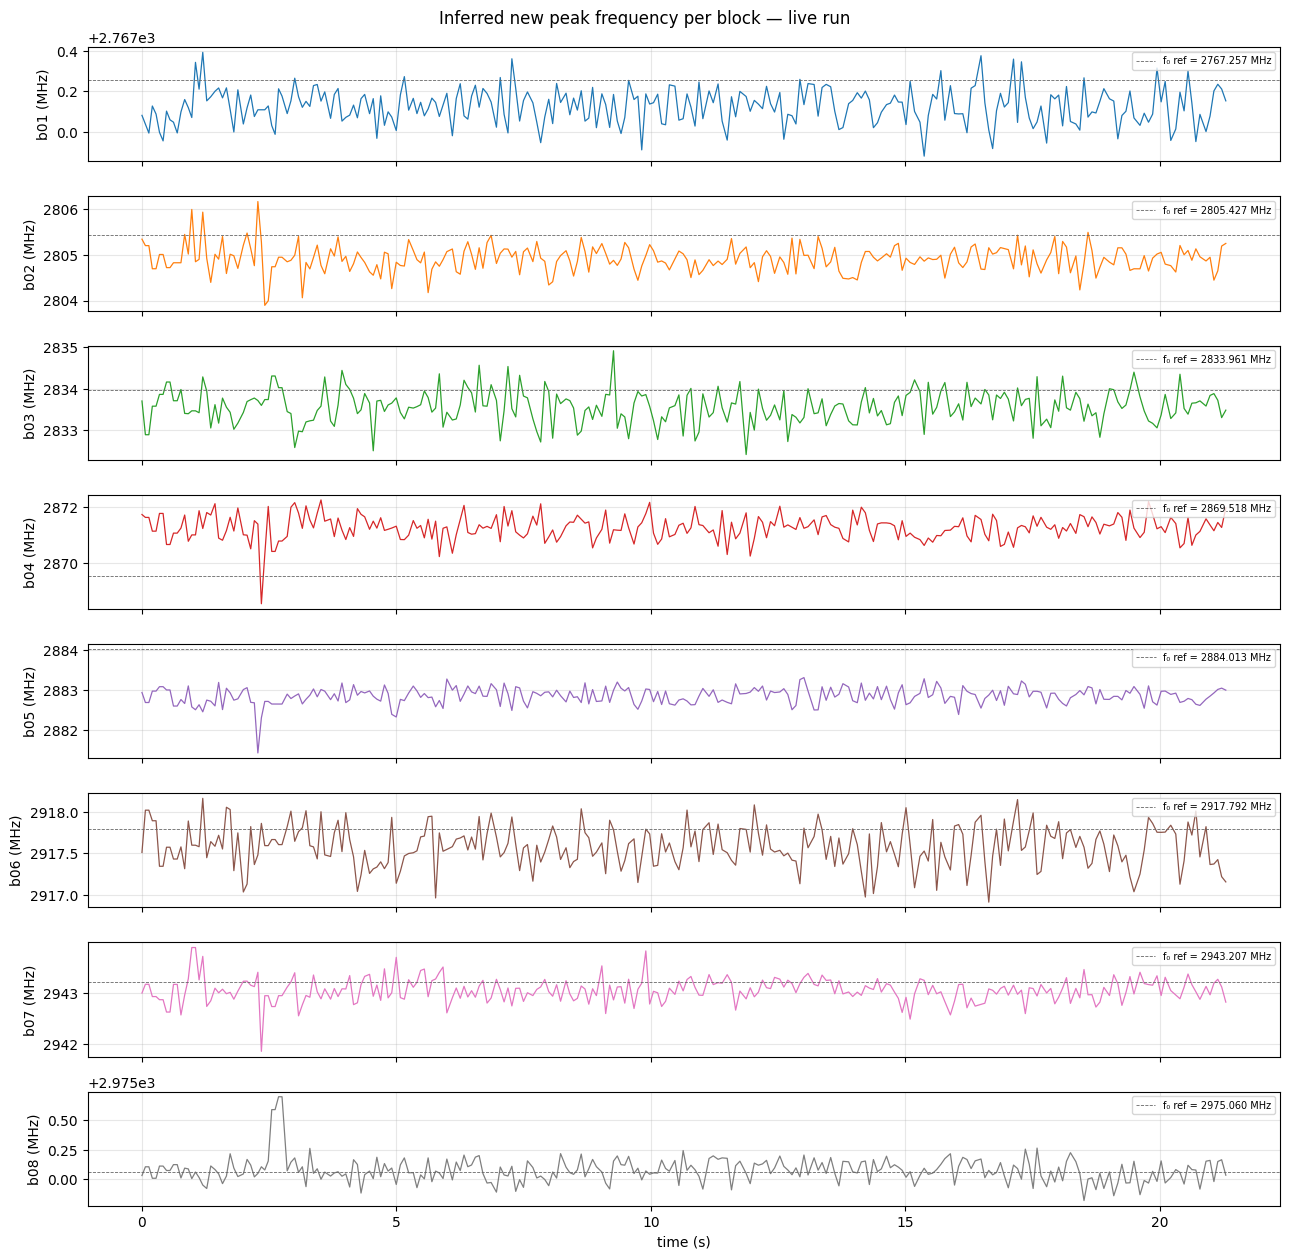


Saved per-block summary to: /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/multipoint_lockin_live_20260514_123219_block_summary.csv


/Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/multipoint_lockin_live_20260514_123219_block_summary.csv

In [40]:
# Post-processing — per-block Δf and new peak frequency over the live run.
# Reads either LIVE_CSV (set by lockin_live) or LIVE_CSV_OVERRIDE if defined.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import FileLink, display

# Resolve which live CSV to process.
if "LIVE_CSV_OVERRIDE" in globals() and LIVE_CSV_OVERRIDE is not None:
    _csv_to_load = Path(LIVE_CSV_OVERRIDE)
elif "LIVE_CSV" in globals() and Path(LIVE_CSV).exists():
    _csv_to_load = Path(LIVE_CSV)
else:
    # Fallback: newest live CSV in data/lockin_multipoint/
    _live_dir = PROJECT_ROOT / "data" / "lockin_multipoint"
    _candidates = sorted(_live_dir.glob("multipoint_lockin_live_*.csv"))
    if not _candidates:
        raise FileNotFoundError(f"No multipoint_lockin_live_*.csv found in {_live_dir}")
    _csv_to_load = _candidates[-1]
print(f"Processing live CSV: {_csv_to_load.name}")

df_live_loaded = pd.read_csv(_csv_to_load)
print(f"  {len(df_live_loaded)} batches over {df_live_loaded['time_s'].iloc[-1]:.1f} s")

# Identify which blocks the file actually has columns for (handles partial runs).
_block_cols = sorted(int(c.split("_b")[-1]) for c in df_live_loaded.columns if c.startswith("delta_f_mhz_b"))
if not _block_cols:
    raise RuntimeError("No delta_f_mhz_b<NN> columns in this CSV — was it produced by lockin_live?")
print(f"  Blocks present: {_block_cols}")

# --- Per-block summary table ---
_summary_rows = []
for k in _block_cols:
    df_col = f"delta_f_mhz_b{k:02d}"
    fnew_col = f"f_new_mhz_b{k:02d}"
    _summary_rows.append({
        "block":               k,
        "n_samples":           int(df_live_loaded[df_col].count()),
        "delta_f_mean_mhz":    float(df_live_loaded[df_col].mean()),
        "delta_f_std_mhz":     float(df_live_loaded[df_col].std()),
        "delta_f_min_mhz":     float(df_live_loaded[df_col].min()),
        "delta_f_max_mhz":     float(df_live_loaded[df_col].max()),
        "f_new_mean_mhz":      float(df_live_loaded[fnew_col].mean()),
        "f_new_std_mhz":       float(df_live_loaded[fnew_col].std()),
        # Sensitivity-to-uT requires the calibration's sensitivity_norm; reuse
        # `calibrations` if it's still in scope, otherwise leave NaN.
        "delta_B_proj_std_uT": (
            float(df_live_loaded[df_col].std() / calibrations[k].sensitivity_norm_mhz_per_mT * 1000.0)
            if "calibrations" in globals() and k in calibrations and calibrations[k].sensitivity_norm_mhz_per_mT > 0
            else float("nan")
        ),
    })
df_block_summary = pd.DataFrame(_summary_rows)
print("\nPer-block summary (live run):")
display(df_block_summary)

# --- Plot 1: Δf per block vs time ---
fig, ax = plt.subplots(figsize=(13, 4.5))
_colors = plt.cm.tab10(np.linspace(0, 1, max(10, len(_block_cols))))
for i, k in enumerate(_block_cols):
    ax.plot(df_live_loaded["time_s"], df_live_loaded[f"delta_f_mhz_b{k:02d}"],
            color=_colors[i % len(_colors)], lw=0.9, label=f"block {k}")
ax.axhline(0, color="0.4", lw=0.5)
ax.set(xlabel="time (s)", ylabel="Δf (MHz)",
       title=f"Live two-point lock-in error signal — {_csv_to_load.name}")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, ncol=4, loc="best")
plt.tight_layout()
plt.show()

# --- Plot 2: f_new per block vs time, with each block's reference f₀ as a dashed line ---
fig, axes = plt.subplots(len(_block_cols), 1, figsize=(13, 1.6 * len(_block_cols)),
                         sharex=True, squeeze=False)
for i, k in enumerate(_block_cols):
    a = axes[i, 0]
    a.plot(df_live_loaded["time_s"], df_live_loaded[f"f_new_mhz_b{k:02d}"],
           color=_colors[i % len(_colors)], lw=0.9)
    f0_col = f"f_new_mhz_b{k:02d}"
    f0_ref = df_live_loaded[f0_col].iloc[0] - df_live_loaded[f"delta_f_mhz_b{k:02d}"].iloc[0]
    a.axhline(f0_ref, color="0.4", ls="--", lw=0.6, label=f"f₀ ref = {f0_ref:.3f} MHz")
    a.set_ylabel(f"b{k:02d} (MHz)")
    a.grid(True, alpha=0.3)
    a.legend(fontsize=7, loc="upper right")
axes[-1, 0].set_xlabel("time (s)")
fig.suptitle("Inferred new peak frequency per block — live run")
plt.tight_layout()
plt.show()

# Save the summary table for later reference.
SUMMARY_CSV = _csv_to_load.with_name(_csv_to_load.stem + "_block_summary.csv")
df_block_summary.to_csv(SUMMARY_CSV, index=False)
print(f"\nSaved per-block summary to: {SUMMARY_CSV}")
display(FileLink(str(SUMMARY_CSV)))


Reconstructing B-field from: multipoint_lockin_live_20260514_123219.csv
status:  ok
samples: 266  rank-ok: 266
vector CSV:     /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/multipoint_lockin_live_20260514_123219_vector_rows.csv
projection CSV: /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/multipoint_lockin_live_20260514_123219_projection_rows.csv


/Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/multipoint_lockin_live_20260514_123219_vector_rows.csv

/Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/multipoint_lockin_live_20260514_123219_projection_rows.csv

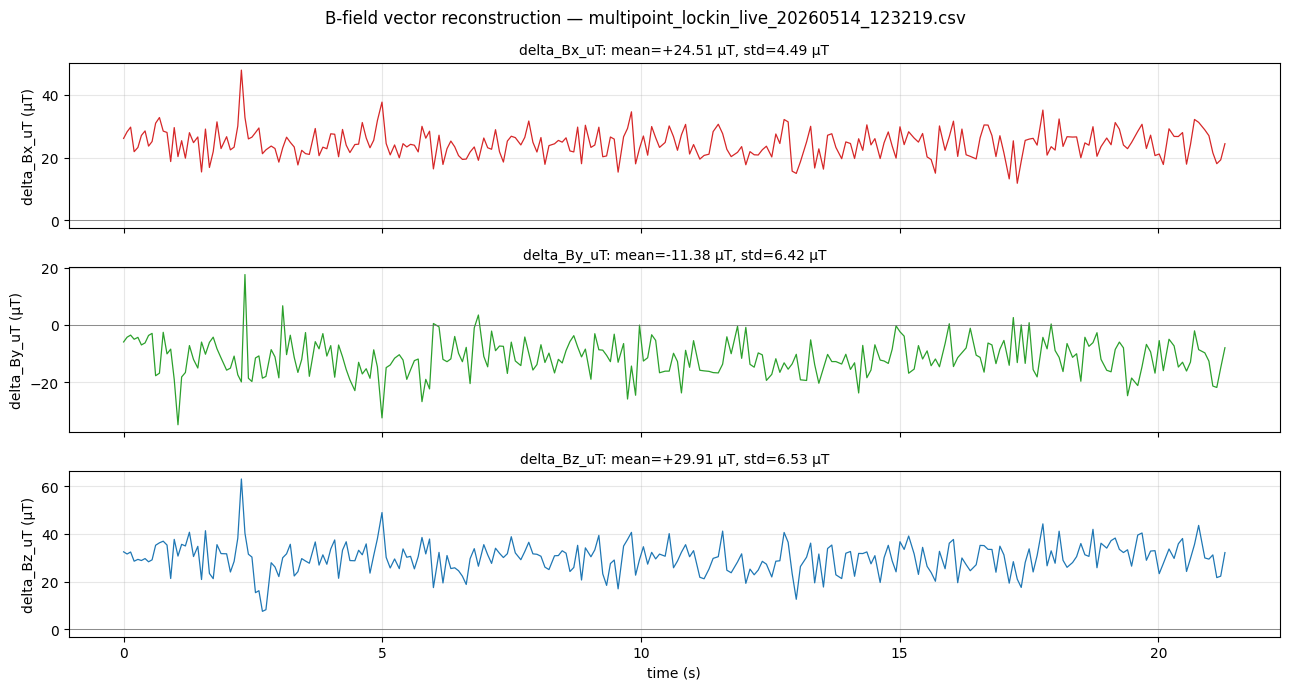

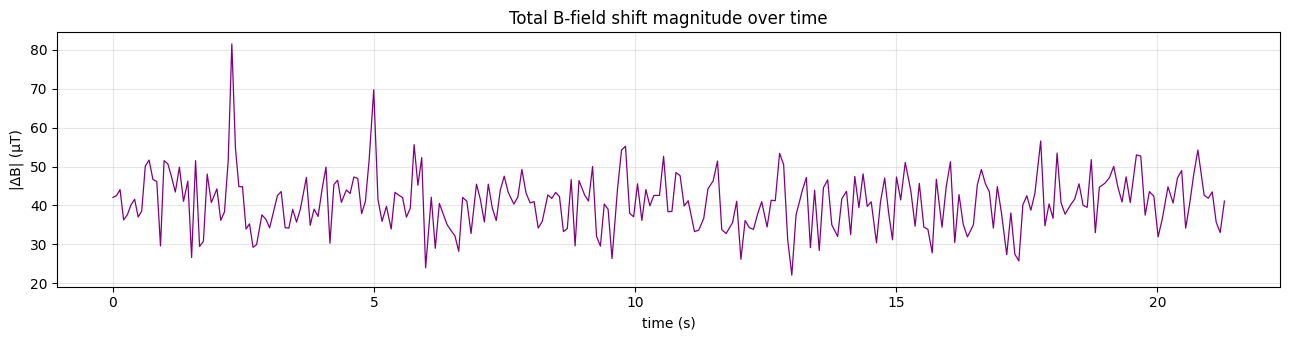

In [41]:
# Post-processing — full B-field vector reconstruction on the live run.
# Calls nv_toolkit._compute_live_snapshot on the wide-format peak columns.
import csv
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import FileLink, display

from nv_toolkit.tui import OperatorConfig, _compute_live_snapshot

# Reuse the resolved CSV from the previous cell, or resolve again here.
if "_csv_to_load" in globals() and Path(_csv_to_load).exists():
    _live_csv_path = Path(_csv_to_load)
elif "LIVE_CSV_OVERRIDE" in globals() and LIVE_CSV_OVERRIDE is not None:
    _live_csv_path = Path(LIVE_CSV_OVERRIDE)
elif "LIVE_CSV" in globals() and Path(LIVE_CSV).exists():
    _live_csv_path = Path(LIVE_CSV)
else:
    _live_dir = PROJECT_ROOT / "data" / "lockin_multipoint"
    _candidates = sorted(_live_dir.glob("multipoint_lockin_live_*.csv"))
    if not _candidates:
        raise FileNotFoundError(f"No multipoint_lockin_live_*.csv found in {_live_dir}")
    _live_csv_path = _candidates[-1]
print(f"Reconstructing B-field from: {_live_csv_path.name}")

# Build the clean wide format _compute_live_snapshot expects: time_s + peak_NN only.
# Each peak column is normalised by its per-batch off-resonance reference (peak_NN_ref)
# so the values match the calibration's normalised scale (calibration is built from
# `measured = mw_on / np.median(mw_on)` inside _load_operator_full_scan). Without this
# normalisation the toolkit returns ~10^5 µT garbage.
df_live_loaded = pd.read_csv(_live_csv_path)
_n_freqs = len(MULTIPOINT_FREQS_MHZ)
_wide_for_recon_live = _live_csv_path.with_name(_live_csv_path.stem + "_wide.csv")
_clean = pd.DataFrame({"time_s": df_live_loaded["time_s"]})
for k in range(_n_freqs):
    _clean[f"peak_{k+1:02d}"] = df_live_loaded[f"peak_{k+1:02d}"] / df_live_loaded[f"peak_{k+1:02d}_ref"]
_clean.to_csv(_wide_for_recon_live, index=False)

# Run the reconstruction.
_bias_mT = BIAS_MT if BIAS_MT is not None else np.zeros(3, dtype=float)
config_live = OperatorConfig(
    full_scan_path=ODMR_CSV_FOR_PLAN,
    parked_data_path=_wide_for_recon_live,
    parked_format="wide",
    bias_field_mT=np.asarray(_bias_mT, dtype=float),
    reference_freqs_mhz=np.asarray(freqs_mhz, dtype=float),
    reference_spectrum=np.asarray(measured, dtype=float),
    transition_centers_mhz=np.asarray(transition_centers, dtype=float),
    parked_plan=tuple(parked_plan),
    plan_csv_path=PARKED_PLAN_CSV,
    wide_template_path=PARKED_PLAN_CSV.with_name("parked_template_wide.csv"),
    long_template_path=PARKED_PLAN_CSV.with_name("parked_template_long.csv"),
    poll_interval_s=0.0,
)
snapshot_live = _compute_live_snapshot(config_live)
if snapshot_live.status == "error":
    raise ValueError(snapshot_live.message)

# Save vector and projection CSVs.
VECTOR_CSV_LIVE     = _live_csv_path.with_name(_live_csv_path.stem + "_vector_rows.csv")
PROJECTION_CSV_LIVE = _live_csv_path.with_name(_live_csv_path.stem + "_projection_rows.csv")

def _write_rows(path, rows):
    if not rows:
        path.write_text("")
        return
    fieldnames = []
    for r in rows:
        for key in r:
            if key not in fieldnames:
                fieldnames.append(str(key))
    with path.open("w", newline="") as h:
        writer = csv.DictWriter(h, fieldnames=fieldnames)
        writer.writeheader()
        for r in rows:
            writer.writerow({k: r.get(k, "") for k in fieldnames})

_write_rows(VECTOR_CSV_LIVE,     snapshot_live.vector_rows)
_write_rows(PROJECTION_CSV_LIVE, snapshot_live.projection_rows)

print(f"status:  {snapshot_live.status}")
print(f"samples: {snapshot_live.sample_count}  rank-ok: {snapshot_live.ok_count}")
print(f"vector CSV:     {VECTOR_CSV_LIVE}")
print(f"projection CSV: {PROJECTION_CSV_LIVE}")
display(FileLink(str(VECTOR_CSV_LIVE)))
display(FileLink(str(PROJECTION_CSV_LIVE)))

# --- Plot ΔBx, ΔBy, ΔBz over time ---
df_vec_live = pd.DataFrame(snapshot_live.vector_rows)
if df_vec_live.empty:
    print("No vector rows to plot — reconstruction may have failed for every sample.")
else:
    # Time axis: prefer time_s if it's there, else timestamp_epoch_s normalized to 0.
    if "time_s" in df_vec_live.columns:
        t_axis = df_vec_live["time_s"].astype(float).to_numpy()
    elif "timestamp_epoch_s" in df_vec_live.columns:
        ts = df_vec_live["timestamp_epoch_s"].astype(float).to_numpy()
        t_axis = ts - ts[0]
    else:
        t_axis = np.arange(len(df_vec_live), dtype=float)

    fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)
    for ax, comp, color in zip(axes, ["delta_Bx_uT", "delta_By_uT", "delta_Bz_uT"],
                                      ["tab:red", "tab:green", "tab:blue"]):
        if comp in df_vec_live.columns:
            ax.plot(t_axis, df_vec_live[comp].astype(float), color=color, lw=0.9)
            ax.set_ylabel(f"{comp} (µT)")
            mu = float(df_vec_live[comp].astype(float).mean())
            sd = float(df_vec_live[comp].astype(float).std())
            ax.set_title(f"{comp}: mean={mu:+.2f} µT, std={sd:.2f} µT", fontsize=10)
        ax.axhline(0, color="0.4", lw=0.5)
        ax.grid(True, alpha=0.3)
    axes[-1].set_xlabel("time (s)")
    fig.suptitle(f"B-field vector reconstruction — {_live_csv_path.name}")
    plt.tight_layout()
    plt.show()

    # Optional total magnitude trace.
    if all(c in df_vec_live.columns for c in ["delta_Bx_uT", "delta_By_uT", "delta_Bz_uT"]):
        bx = df_vec_live["delta_Bx_uT"].astype(float).to_numpy()
        by = df_vec_live["delta_By_uT"].astype(float).to_numpy()
        bz = df_vec_live["delta_Bz_uT"].astype(float).to_numpy()
        magnitude = np.sqrt(bx**2 + by**2 + bz**2)
        fig, ax = plt.subplots(figsize=(13, 3.5))
        ax.plot(t_axis, magnitude, color="purple", lw=0.9)
        ax.set(xlabel="time (s)", ylabel="|ΔB| (µT)",
               title="Total B-field shift magnitude over time")
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


# Live B field

Built LIVE B-field program for 16 freqs, 10 reps/batch, predicted ~69 ms/batch
Priming once with pre_init=True...
Priming done. Entering live B-field loop.

Spike rejection: enabled=True, window=7, k_sigma=4.0, warmup=4, sigma_floor=1.5, baseline=/Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/multipoint_lockin_collected.csv



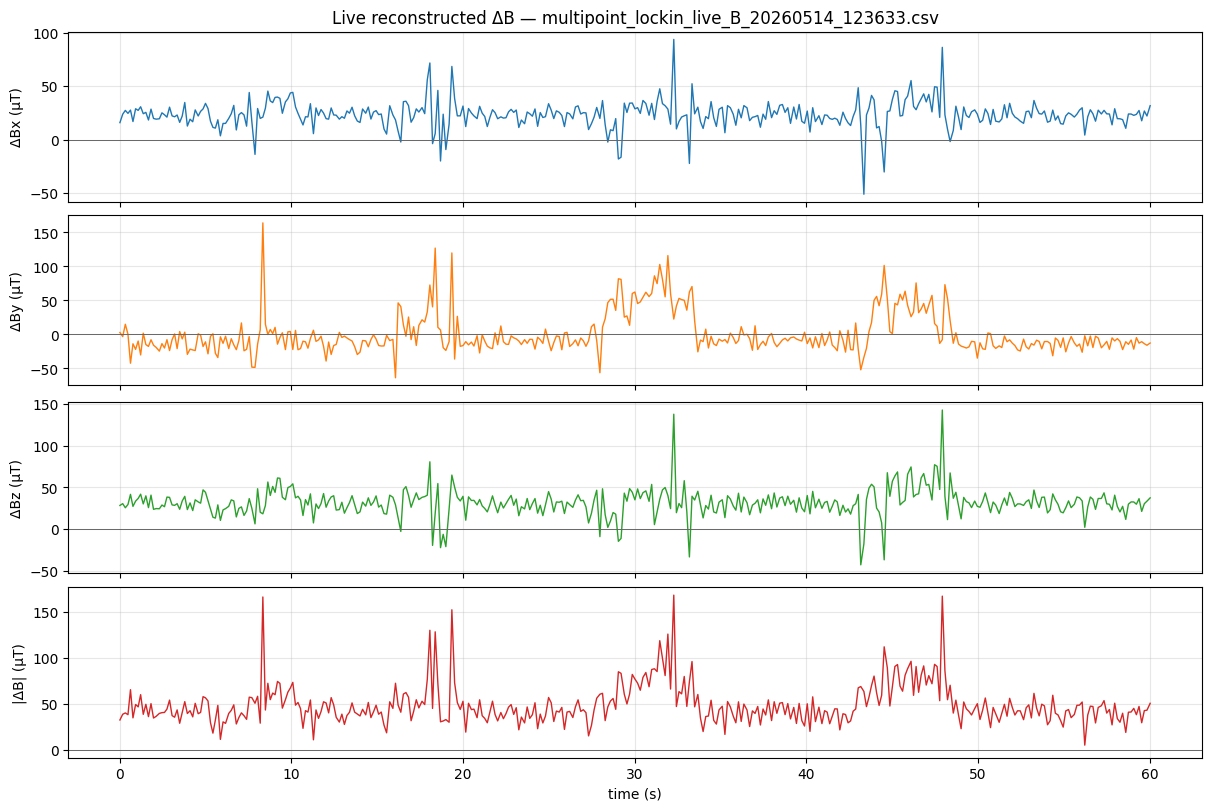


Live B-field run finished: 387 batches in 60.0 s
Saved to: /Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/multipoint_lockin_live_B_20260514_123633.csv


/Users/ckasemtantikul/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/data/lockin_multipoint/multipoint_lockin_live_B_20260514_123633.csv

Per-batch timing (ms): predicted ~69, actual median=12, p95=14, max=15

Spike rejection: 415 signal-channel rejections, 404 reference-channel rejections (6.70% of signal cells, 6.52% of reference cells).


,batch,time_s,timestamp_epoch_s,acq_seconds,peak_01,peak_01_ref,peak_01_freq_mhz,peak_01_spike_sig,peak_01_spike_ref,peak_02,...,delta_f_mhz_b08,delta_B_proj_uT_b08,delta_Bx_uT,delta_By_uT,delta_Bz_uT,delta_B_total_uT,B_residual_uT,B_status,B_rank,B_condition_number
382,382,59.382280,1.778780e+09,0.012910,6919.100070,6921.336998,2761.973177,False,False,6917.870965,...,-0.051726,-1.843398,27.360141,-12.875874,36.427886,47.342965,112.932306,ok,3,9.735704
383,383,59.537351,1.778780e+09,0.012262,6918.553622,6921.801314,2761.973177,False,False,6917.113197,...,0.057325,2.042933,17.710822,-10.776351,21.131366,29.603000,52.922437,ok,3,9.735704
384,384,59.690879,1.778780e+09,0.011867,6916.576515,6922.030409,2761.973177,False,False,6917.524895,...,0.050976,1.816675,26.861944,-13.738850,30.384219,42.819631,52.703666,ok,3,9.735704
385,385,59.843938,1.778780e+09,0.012294,6917.905998,6919.989962,2761.973177,False,False,6915.726981,...,-0.113121,-4.031404,22.213295,-16.014189,33.451372,43.230533,73.836900,ok,3,9.735704
386,386,60.029911,1.778780e+09,0.013871,6917.325504,6921.283709,2761.973177,False,False,6918.526359,...,0.112392,4.005425,31.849748,-12.727544,37.398251,50.744714,44.670998,ok,3,9.735704


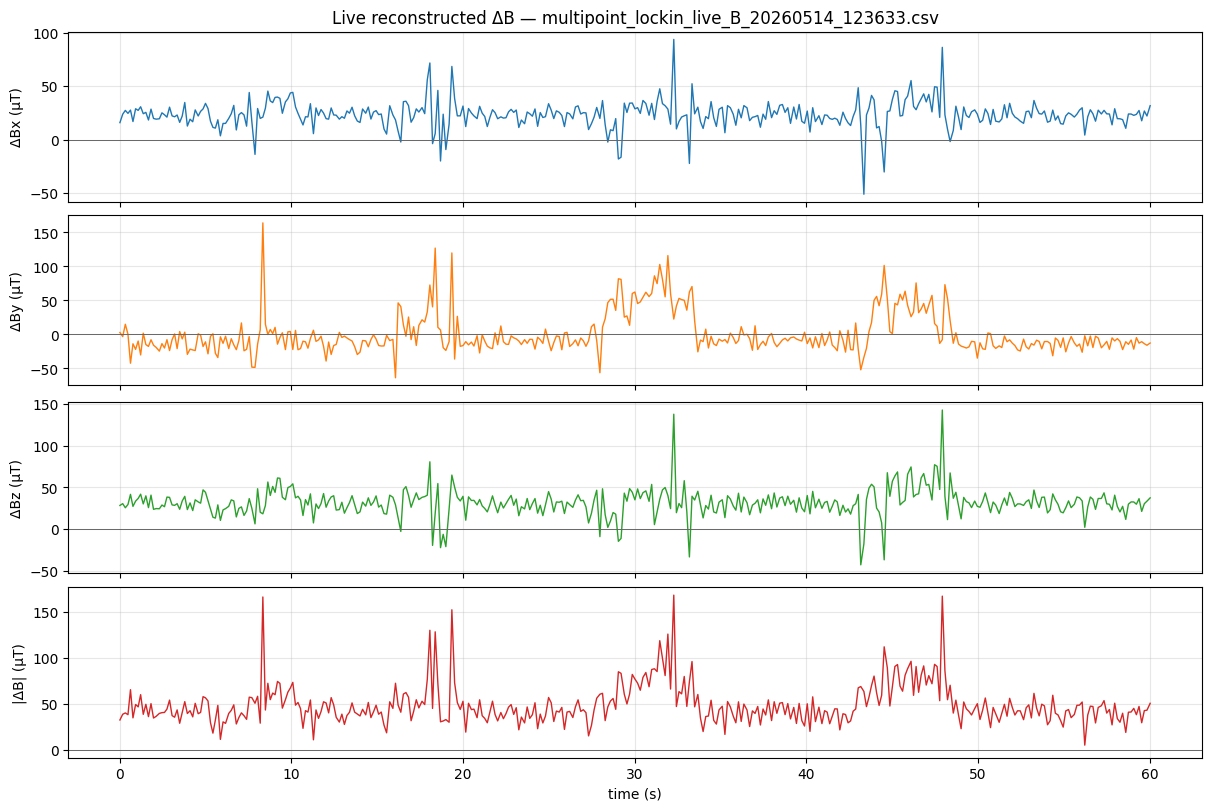

In [45]:
# Step 4B — Live magnetic-field reconstruction using the same toolkit pipeline as Step 4.
# Per batch we normalise (signal/reference) so the values match the calibration's
# normalised scale, then feed them to estimate_parked_series_fields →
# reconstruct_vector_timeseries — the same code path _compute_live_snapshot uses.
#
# SPIKE REJECTION (added 2026-05-13): same causal Hampel filter as Step 4,
# applied to d_batch.signal and d_batch.reference before normalisation. The
# Live B cell maintains its own despiker state (independent from Step 4).

import importlib
from copy import copy
from pathlib import Path
from time import perf_counter, time as _wallclock
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import FileLink, display

from nv_toolkit.intensity_tracking import (
    estimate_parked_series_fields,
    reconstruct_vector_timeseries,
)

import multipoint_lockin_program
multipoint_lockin_program = importlib.reload(multipoint_lockin_program)
from multipoint_lockin_program import MultipointLockinODMR

import spike_rejection
spike_rejection = importlib.reload(spike_rejection)
from spike_rejection import HampelDespiker

if "calibrations" not in globals() or len(calibrations) == 0:
    raise RuntimeError("Run the lockin_to_peak_frequency cell first so calibrations exists.")
for _name in ("_block_indices", "_point_in_block", "_parked_freqs"):
    if _name not in globals():
        raise RuntimeError(f"{_name} not in globals — run lockin_to_peak_frequency first.")

# --- Live parameters (identical to Step 4) ---
LIVE_REPS_PER_BATCH       = 10
LIVE_DURATION_SEC         = 60.0
LIVE_PLOT_REFRESH_EVERY   = 1
LIVE_OFF_RESONANCE_MHZ    = MULTIPOINT_OFF_RESONANCE_MHZ if "MULTIPOINT_OFF_RESONANCE_MHZ" in globals() else 2650.0
LIVE_RELAX_DELAY_TREG     = 1000
LIVE_WATCHDOG_FACTOR      = 3.0

# --- Spike rejection parameters (independent state from Step 4) ---
LIVE_B_DESPIKE_ENABLED   = True
LIVE_B_DESPIKE_WINDOW    = 7
LIVE_B_DESPIKE_K_SIGMA   = 4.0
LIVE_B_DESPIKE_WARMUP    = 4
LIVE_B_DESPIKE_SIGMA_FLOOR = 1.5

_run_stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
LIVE_B_CSV = PROJECT_ROOT / "data" / "lockin_multipoint" / f"multipoint_lockin_live_B_{_run_stamp}.csv"
LIVE_B_CSV.parent.mkdir(parents=True, exist_ok=True)

# --- Build live multipoint program (pre_init=False, like Step 4) ---
cfg_live = copy(default_config)
cfg_live.multipoint_freqs_mhz       = list(MULTIPOINT_FREQS_MHZ)
cfg_live.odmr_reference_offres_mhz  = LIVE_OFF_RESONANCE_MHZ
cfg_live.relax_delay_treg           = int(LIVE_RELAX_DELAY_TREG)
cfg_live.mw_start_fMHz              = float(MULTIPOINT_FREQS_MHZ[0])
cfg_live.mw_end_fMHz                = float(MULTIPOINT_FREQS_MHZ[0])
cfg_live.nsweep_points              = 1
cfg_live.reps                       = int(LIVE_REPS_PER_BATCH)
cfg_live.pre_init                   = False

prog_live = MultipointLockinODMR(cfg_live)
_predicted_ms_per_batch = prog_live.total_time() * 1e3
print(f"Built LIVE B-field program for {len(MULTIPOINT_FREQS_MHZ)} freqs, "
      f"{cfg_live.reps} reps/batch, predicted ~{_predicted_ms_per_batch:.0f} ms/batch")

# --- Prime once with pre_init=True (same as Step 4) ---
cfg_prime = copy(cfg_live)
cfg_prime.pre_init = True
prog_prime = MultipointLockinODMR(cfg_prime)
print("Priming once with pre_init=True...")
_ = prog_prime.acquire(progress=False)
del prog_prime, cfg_prime
print("Priming done. Entering live B-field loop.\n")

# --- Spike rejection setup ---
_sig_baseline = None
_ref_baseline = None
_baseline_src = "(none)"
if LIVE_B_DESPIKE_ENABLED:
    try:
        _bl_row = pd.read_csv(MULTIPOINT_DATA_CSV).iloc[-1]
        _sig_baseline = np.array([float(_bl_row[f"peak_{i:02d}"])     for i in range(1, 17)])
        _ref_baseline = np.array([float(_bl_row[f"peak_{i:02d}_ref"]) for i in range(1, 17)])
        _baseline_src = str(MULTIPOINT_DATA_CSV)
    except Exception as _e:
        print(f"  (despike) no single-batch baseline available ({_e}); warm-up will pass samples through.")
despiker_sig_B = HampelDespiker(
    n_channels=16,
    window=LIVE_B_DESPIKE_WINDOW,
    k_sigma=LIVE_B_DESPIKE_K_SIGMA,
    min_warmup=LIVE_B_DESPIKE_WARMUP,
    sigma_floor=LIVE_B_DESPIKE_SIGMA_FLOOR,
    baseline=_sig_baseline,
)
despiker_ref_B = HampelDespiker(
    n_channels=16,
    window=LIVE_B_DESPIKE_WINDOW,
    k_sigma=LIVE_B_DESPIKE_K_SIGMA,
    min_warmup=LIVE_B_DESPIKE_WARMUP,
    sigma_floor=LIVE_B_DESPIKE_SIGMA_FLOOR,
    baseline=_ref_baseline,
)
print(f"Spike rejection: enabled={LIVE_B_DESPIKE_ENABLED}, window={LIVE_B_DESPIKE_WINDOW}, "
      f"k_sigma={LIVE_B_DESPIKE_K_SIGMA}, warmup={LIVE_B_DESPIKE_WARMUP}, "
      f"sigma_floor={LIVE_B_DESPIKE_SIGMA_FLOOR}, baseline={_baseline_src}\n")

# --- Block indexing arrays the toolkit needs (built in lockin_to_peak_frequency) ---
_block_indices_arr  = np.asarray(_block_indices,  dtype=int)
_point_in_block_arr = np.asarray(_point_in_block, dtype=int)
_parked_freqs_arr   = np.asarray(_parked_freqs,   dtype=float)

# --- Live plot ---
plt.ion()
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True, constrained_layout=True)
line_Bx, = axes[0].plot([], [], lw=1.0, color="tab:blue")
line_By, = axes[1].plot([], [], lw=1.0, color="tab:orange")
line_Bz, = axes[2].plot([], [], lw=1.0, color="tab:green")
line_Bt, = axes[3].plot([], [], lw=1.0, color="tab:red")
axes[0].set_ylabel("ΔBx (µT)")
axes[1].set_ylabel("ΔBy (µT)")
axes[2].set_ylabel("ΔBz (µT)")
axes[3].set_ylabel("|ΔB| (µT)")
axes[3].set_xlabel("time (s)")
for ax in axes:
    ax.axhline(0, color="0.4", lw=0.7)
    ax.grid(True, alpha=0.3)
axes[0].set_title(f"Live reconstructed ΔB — {LIVE_B_CSV.name}")
_handle = display(fig, display_id=True)

# --- Live loop ---
rows = []
time_history = []
Bx_history = []; By_history = []; Bz_history = []; Btot_history = []
_acq_seconds_history = []
_n_spike_sig_total = 0
_n_spike_ref_total = 0

t0 = perf_counter()
batch = 0
last_save_t = t0
SAVE_EVERY_SEC = 5.0
_n_watchdog_warnings = 0

try:
    while True:
        t_start = perf_counter() - t0
        d_batch = prog_live.acquire(progress=False)
        t_end = perf_counter() - t0
        t_mid = 0.5 * (t_start + t_end)
        wall_now = _wallclock()
        acq_dt = t_end - t_start
        _acq_seconds_history.append(acq_dt)

        if acq_dt * 1000 > _predicted_ms_per_batch * LIVE_WATCHDOG_FACTOR and _n_watchdog_warnings < 5:
            print(f"  batch {batch}: acq_seconds={acq_dt*1000:.0f} ms "
                  f"(predicted ~{_predicted_ms_per_batch:.0f} ms)")
            _n_watchdog_warnings += 1

        # ---- Spike rejection on raw ADC (per parked-point) ----
        sig_raw = np.asarray(d_batch.signal,    dtype=float)
        ref_raw = np.asarray(d_batch.reference, dtype=float)
        if LIVE_B_DESPIKE_ENABLED:
            sig_clean, sig_flags = despiker_sig_B.update(sig_raw)
            ref_clean, ref_flags = despiker_ref_B.update(ref_raw)
        else:
            sig_clean, ref_clean = sig_raw, ref_raw
            sig_flags = np.zeros(16, dtype=bool)
            ref_flags = np.zeros(16, dtype=bool)
        _n_spike_sig_total += int(sig_flags.sum())
        _n_spike_ref_total += int(ref_flags.sum())

        # Same row format as Step 4 (raw peak / ref / freq columns).
        # Values stored here are *despiked*; flags record where replacements happened.
        row = {
            "batch": batch,
            "time_s": t_mid,
            "timestamp_epoch_s": wall_now,
            "acq_seconds": acq_dt,
        }
        for k_idx, (f, s, r) in enumerate(
            zip(d_batch.frequencies_mhz, sig_clean, ref_clean)
        ):
            row[f"peak_{k_idx+1:02d}"]           = float(s)
            row[f"peak_{k_idx+1:02d}_ref"]       = float(r)
            row[f"peak_{k_idx+1:02d}_freq_mhz"]  = float(f)
            row[f"peak_{k_idx+1:02d}_spike_sig"] = bool(sig_flags[k_idx])
            row[f"peak_{k_idx+1:02d}_spike_ref"] = bool(ref_flags[k_idx])

        # ---- Toolkit-correct ΔB reconstruction (normalised signal/reference, single-row call) ----
        intensities_single = (sig_clean / ref_clean).reshape(1, -1)
        timestamps_single  = np.asarray([wall_now], dtype=float)
        save_ids_single    = [str(batch)]

        projection_rows_b = estimate_parked_series_fields(
            intensities_single,
            timestamps_single,
            save_ids_single,
            _block_indices_arr,
            _point_in_block_arr,
            _parked_freqs_arr,
            calibrations,
            nv_axes_preset="qdm",
            search_radius_mT=0.0,
        )
        vector_rows_b = reconstruct_vector_timeseries(projection_rows_b, min_channels=3)
        vrow = vector_rows_b[0]

        Bx_uT = float(vrow.get("delta_Bx_uT", np.nan))
        By_uT = float(vrow.get("delta_By_uT", np.nan))
        Bz_uT = float(vrow.get("delta_Bz_uT", np.nan))
        residual_uT = float(vrow.get("residual_norm_uT", np.nan))
        Btot_uT = float(np.sqrt(Bx_uT**2 + By_uT**2 + Bz_uT**2)) if np.isfinite(Bx_uT) else np.nan

        for prow in projection_rows_b:
            b_idx = int(prow["block_index"])
            row[f"delta_f_mhz_b{b_idx:02d}"]      = float(prow["delta_B_projection_mT"]) * float(prow["sensitivity_norm_mhz_per_mT"])
            row[f"delta_B_proj_uT_b{b_idx:02d}"]  = float(prow["delta_B_projection_uT"])

        row["delta_Bx_uT"]        = Bx_uT
        row["delta_By_uT"]        = By_uT
        row["delta_Bz_uT"]        = Bz_uT
        row["delta_B_total_uT"]   = Btot_uT
        row["B_residual_uT"]      = residual_uT
        row["B_status"]           = str(vrow.get("status", "n/a"))
        row["B_rank"]             = int(vrow.get("rank", -1))
        row["B_condition_number"] = float(vrow.get("condition_number", np.nan))

        rows.append(row)
        time_history.append(t_mid)
        Bx_history.append(Bx_uT); By_history.append(By_uT)
        Bz_history.append(Bz_uT); Btot_history.append(Btot_uT)

        if batch % LIVE_PLOT_REFRESH_EVERY == 0:
            line_Bx.set_data(time_history, Bx_history)
            line_By.set_data(time_history, By_history)
            line_Bz.set_data(time_history, Bz_history)
            line_Bt.set_data(time_history, Btot_history)
            for ax in axes:
                ax.relim(); ax.autoscale_view()
            fig.canvas.draw_idle()
            _handle.update(fig)

        if perf_counter() - last_save_t > SAVE_EVERY_SEC:
            pd.DataFrame(rows).to_csv(LIVE_B_CSV, index=False)
            last_save_t = perf_counter()

        batch += 1
        if LIVE_DURATION_SEC is not None and t_end >= LIVE_DURATION_SEC:
            break

except KeyboardInterrupt:
    print(f"Live B-field stopped by user — {batch} batches collected.")
finally:
    plt.ioff()

# --- Final save ---
df_live_B = pd.DataFrame(rows)
df_live_B.to_csv(LIVE_B_CSV, index=False)
print(f"\nLive B-field run finished: {len(df_live_B)} batches in {df_live_B['time_s'].iloc[-1]:.1f} s")
print(f"Saved to: {LIVE_B_CSV}")
display(FileLink(str(LIVE_B_CSV)))

_acq_arr = np.asarray(_acq_seconds_history) * 1000.0
print(f"Per-batch timing (ms): predicted ~{_predicted_ms_per_batch:.0f}, "
      f"actual median={np.median(_acq_arr):.0f}, "
      f"p95={np.percentile(_acq_arr, 95):.0f}, max={_acq_arr.max():.0f}")

if LIVE_B_DESPIKE_ENABLED and len(df_live_B) > 0:
    _n_total_cells = len(df_live_B) * 16
    print(f"\nSpike rejection: {_n_spike_sig_total} signal-channel rejections, "
          f"{_n_spike_ref_total} reference-channel rejections "
          f"({_n_spike_sig_total / _n_total_cells * 100:.2f}% of signal cells, "
          f"{_n_spike_ref_total / _n_total_cells * 100:.2f}% of reference cells).")

display(df_live_B.tail())
